In [1]:
import dpluspy
import demes
import demesdraw
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.transforms import ScaledTranslation
import msprime
import numpy as np
import pickle
import bokeh
import pandas

In [2]:
"""
define filenames, constants etc
"""


def load_pkl(fname):
    with open(fname, "rb") as fin: 
        ret = pickle.load(fin)
    return ret


bherer_data_file = "statistics/main/bherer_stats.pkl"
zhou_data_file = "statistics/main/zhou_stats.pkl"

bherer_data = dpluspy.inference.load_stats(bherer_data_file, return_dict=True)
zhou_data = dpluspy.inference.load_stats(zhou_data_file, return_dict=True)
bherer_data = dpluspy.bootstrapping.subset_stats(
    bherer_data, to_pops=bherer_data["pop_ids"][:8], return_dict=True)
zhou_data = dpluspy.bootstrapping.subset_stats(
    zhou_data, to_pops=zhou_data["pop_ids"][:8], return_dict=True)


_model_cache = {}

def get_model(graph_file, data, u=1.3e-8):
    if (graph_file, u) in _model_cache:
        _model = _model_cache[(graph_file, u)]
    else:
        _model = dpluspy.inference.compute_bin_stats(
            graph_file, sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
        _model_cache[(graph_file, u)] = _model
    model = {
        "means": _model, "bins": data["bins"], "pop_ids": data["pop_ids"]}
    return model

In [3]:


matplotlib.rcParams["font.size"] = 10
matplotlib.rcParams['xtick.labelsize'] = 8
matplotlib.rcParams['ytick.labelsize'] = 8
matplotlib.rcParams['ytick.major.size'] = 2


def plot_stats_on_axs(
    stats, 
    axs, 
    color="tab:blue",
    linestyle="-", 
    labels=None, 
    fill=False,
    alpha=0.3,
    ylabel="$H_2$",
    plot_sqrhet=False,
    sqrhet_color=None,
    scale=1,
    lw = 1.1,
    kwargs={}
):
    shape = axs.shape
    axs = axs.flatten()
    ax_tracker = np.zeros(len(axs), np.int64)
    means = np.array(stats["means"])[:-1]
    if plot_sqrhet:
        hets = np.array(stats["means"])[-1] 
    if fill:
        varcovs = np.array(stats["varcovs"])[:-1]
    bins = stats["bins"]
    xx = 10 ** ((np.log10(bins[1:]) + np.log10(bins[:-1])) / 2)
    pop_ids = stats["pop_ids"]
    statistics = dpluspy.utils._DP_names(list(range(len(pop_ids))))

    mapping = {}
    tally = 0 
    for ii in range(len(pop_ids)):
        for jj in range(ii, len(pop_ids)):
            mapping[(ii, jj)] = tally
            tally += 1

    for (idx0, idx1), ax_idx in mapping.items():
        ax = axs[ax_idx]
        if labels is not None:
            if idx0 == idx1:
                label = labels[idx0]
            else:
                label = f"{labels[idx0]},{labels[idx1]}"
            ax.set_title(label, y=0.8, fontsize="x-small")

        identifier = f"D+_{idx0}_{idx1}"
        idx = statistics.index(identifier)
        yy = means[:, idx] * scale
        # pick the color based on how many curves have been plotted so far
        if fill:
            err = varcovs[:, idx, idx] ** 0.5 * 1.96 * scale
            ax.fill_between(
                xx, yy - err, yy + err, alpha=alpha, color=color, edgecolor="none")
        if linestyle is not None:
            ax.plot(xx, yy, linestyle, color=color, lw=lw, **kwargs)
        if plot_sqrhet:
            if sqrhet_color is None:
                sqrhet_color = color
            Hsqr = hets[idx] ** 2
            ax.scatter(
                [0.60], [Hsqr], marker="+", color=sqrhet_color, linewidth=lw)

        ax_tracker[ax_idx] += 1
    for ax in axs: 
        ax.set_xscale("log")
    # label axes of subplots at the left and bottom edges
    for ax in axs[-shape[1]:]:
        ax.set_xlabel("$r$")
    for ii in range(len(axs)):
        if ii % shape[1] == 0:
            axs[ii].set_ylabel(ylabel)
    return


def compute_residuals(data, model):
    varcovs = data["varcovs"]
    stds = [v[np.diag_indices(len(varcovs[0]))] ** 0.5 for v in varcovs]
    residuals = np.array(model) - np.array(data["means"])
    scaled_residuals = residuals / stds
    return scaled_residuals


def label_ax(ax, label):
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, 4/72, fig.dpi_scale_trans)))
    return


def label_axs(fig, axs):
    # label mosaic subplots 
    for label, ax in axs.items():
        ax.text(0.0, 1.0, label, fontsize="medium", va="bottom", transform=(
            ax.transAxes + ScaledTranslation(-20/72, +0/72, fig.dpi_scale_trans)))
    return

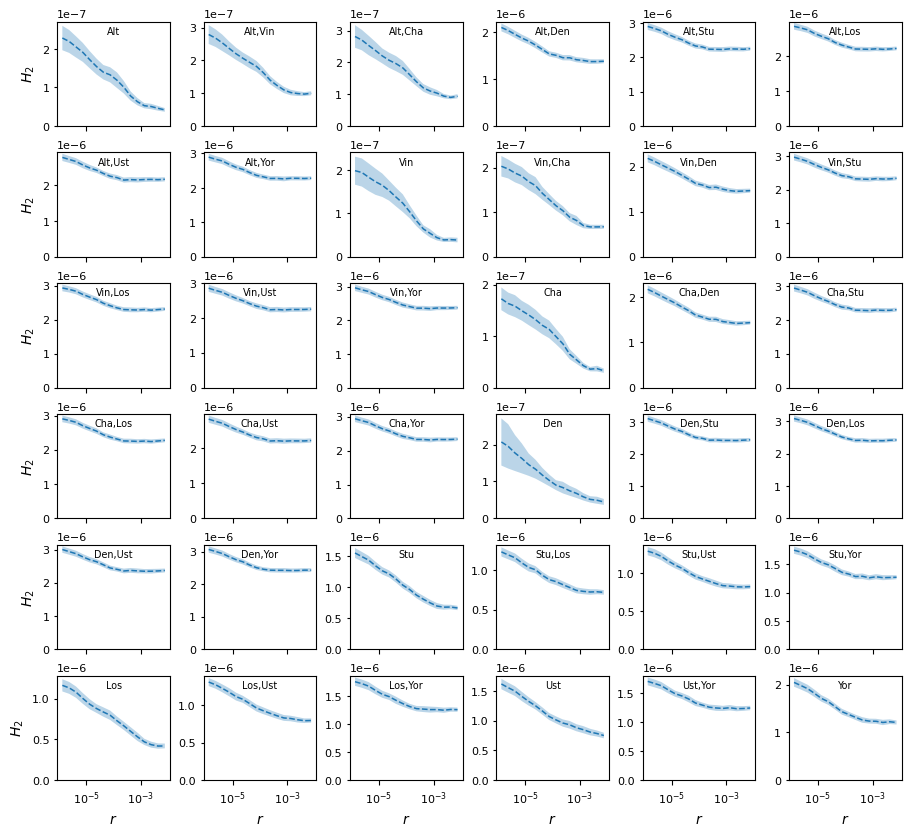

In [5]:
"""
the behrer data set by itself
"""


def plot_bherer_set(axs):
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue",
        linestyle="--",
        labels=labels, 
        fill=True
    )
    for ax in axs.flat:
        ax.set_ylim(0,)
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_bherer_set(axs)
    
plt.savefig("figures/bherer_dataset.pdf")

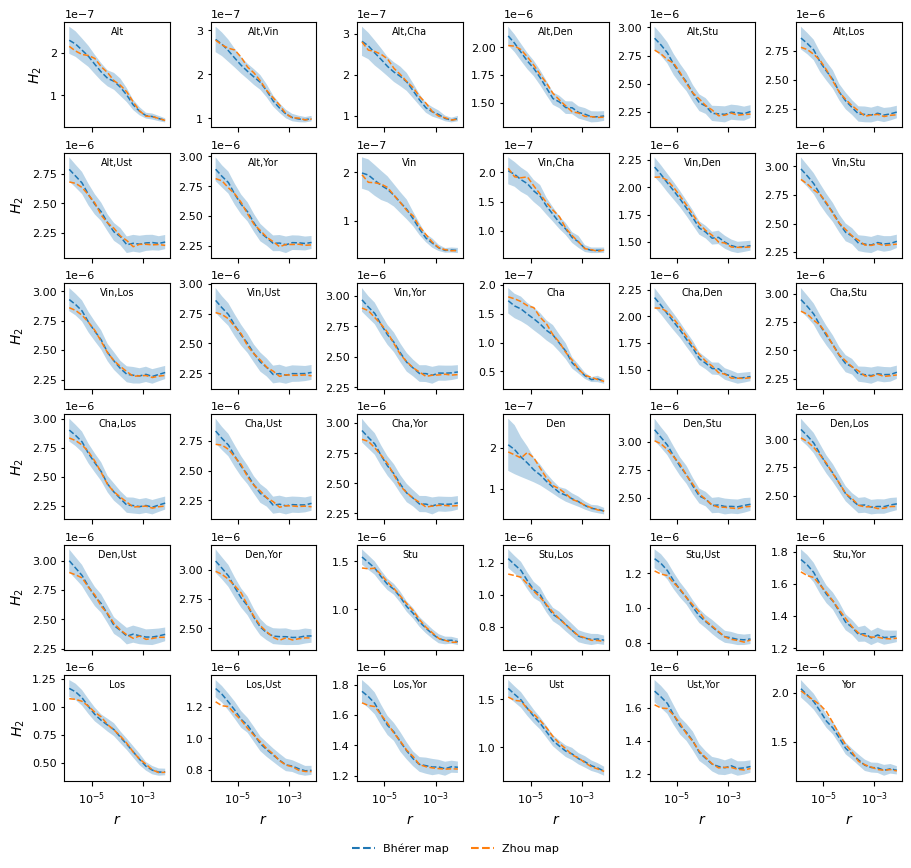

In [7]:
"""
a direct comparison of bherer/zhou data sets
"""


def plot_bherer_zhou_comp(axs):
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue",
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        zhou_data, 
        axs,
        color="tab:orange", 
        linestyle="--", 
        labels=None, 
        fill=False
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_bherer_zhou_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Bhérer map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Zhou map", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.04))
    
plt.savefig("figures/bherer_zhou_map_comp.pdf")

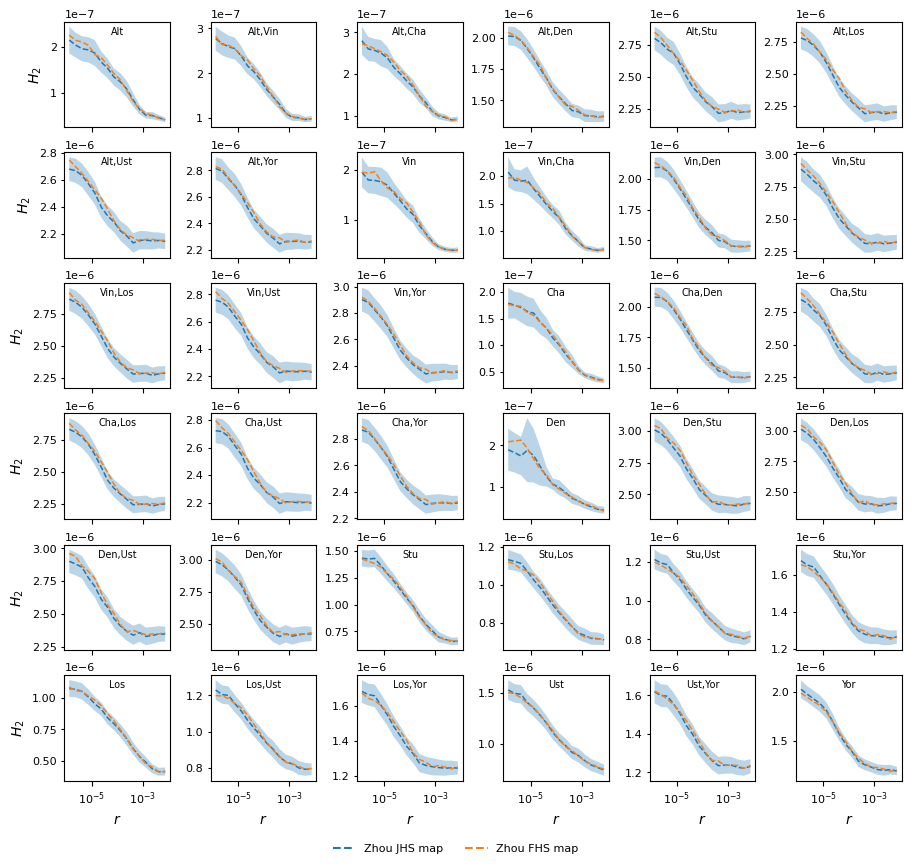

In [29]:
"""
compare the Zhou JHS (alias "zhou") map to the Zhou FHS map (not used in this study)
"""


def plot_zhou_fhs_jhs_comp(axs):
    zhou_fhs_data_file = "statistics/supplementary/placeholder/zhou_FHS_stats.pkl"
    zhou_fhs_data = dpluspy.inference.load_stats(
        zhou_fhs_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        zhou_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        zhou_fhs_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None,
        fill=False
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_zhou_fhs_jhs_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Zhou JHS map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Zhou FHS map", linestyle="--")
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/zhou_jhs_fhs_map_comp.pdf")

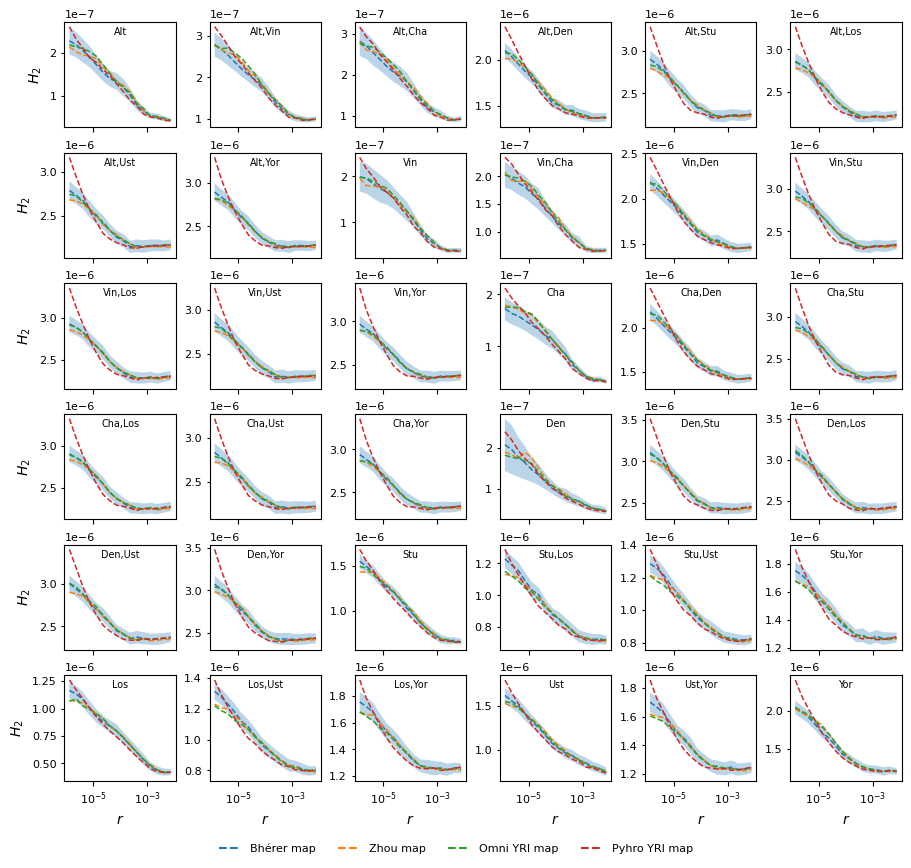

In [28]:
"""
compare the bherer/zhou data sets to omni and pyrho YRI data sets
"""


def plot_ld_map_comp(axs):
    omni_YRI_data_file = "statistics/supplementary/placeholder/omni_YRI_stats.pkl"
    pyrho_YRI_data_file = "statistics/supplementary/placeholder/pyrho_YRI_stats.pkl"

    omni_data = dpluspy.inference.load_stats(
        omni_YRI_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    pyrho_data = dpluspy.inference.load_stats(
        pyrho_YRI_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        zhou_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None,
        fill=False
    )
    plot_stats_on_axs(
        omni_data, 
        axs,
        color="tab:green",
        linestyle="--", 
        labels=None
    )    
    plot_stats_on_axs(
        pyrho_data, 
        axs,
        color="tab:red",
        linestyle="--", 
        labels=None
    )
    return

fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_ld_map_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Bhérer map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Zhou map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label="Omni YRI map", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:red", label="Pyhro YRI map", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/ld_map_comp.pdf")

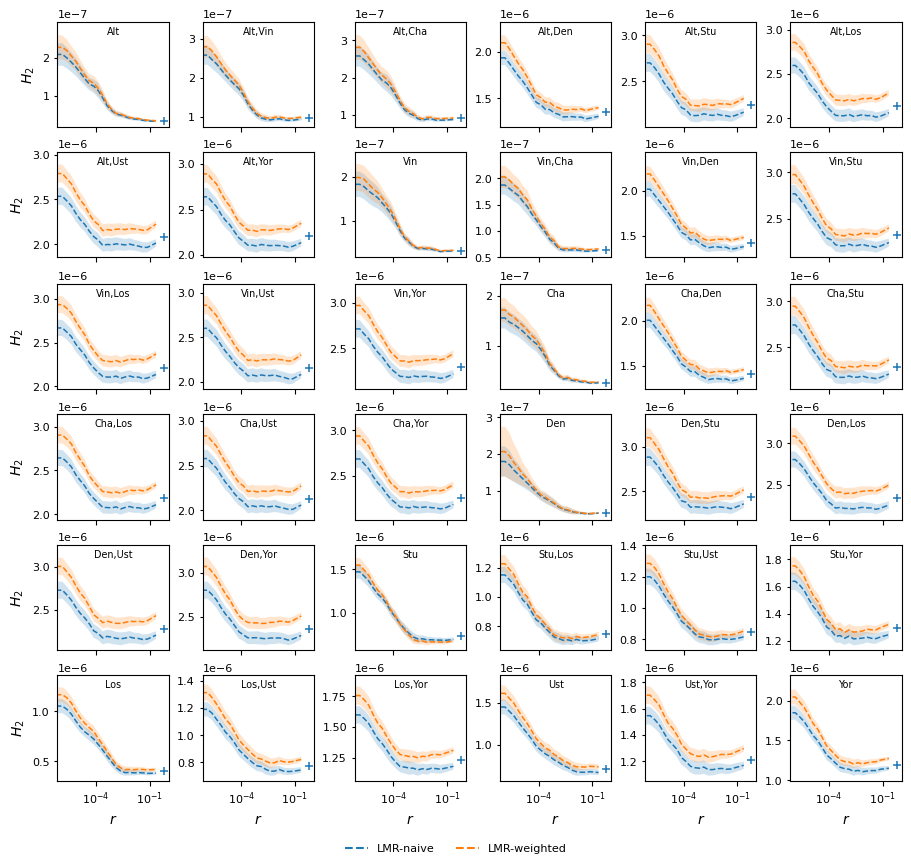

In [19]:
def plot_empirical_weighting_comp_bherer(axs):
    weighted_data_file = "statistics/main/bherer_weighted_stats.pkl"
    naive_data_file = "statistics/main/bherer_naive_stats.pkl"
    weighted_data = dpluspy.inference.load_stats(
        weighted_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    naive_data = dpluspy.inference.load_stats(
        naive_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        naive_data, 
        axs, 
        color="tab:blue", 
        alpha=0.2,
        linestyle="--",
        plot_sqrhet=True,
        labels=labels, 
        fill=True,
    )
    plot_stats_on_axs(
        weighted_data, 
        axs,
        color="tab:orange",
        alpha=0.2,
        linestyle="--", 
        labels=None,
        fill=True
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_empirical_weighting_comp_bherer(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", linestyle="--", label=r"LMR-naive"),
    matplotlib.lines.Line2D([], [], color="tab:orange", linestyle="--", label=r"LMR-weighted"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/weighting_comp_bherer.pdf")

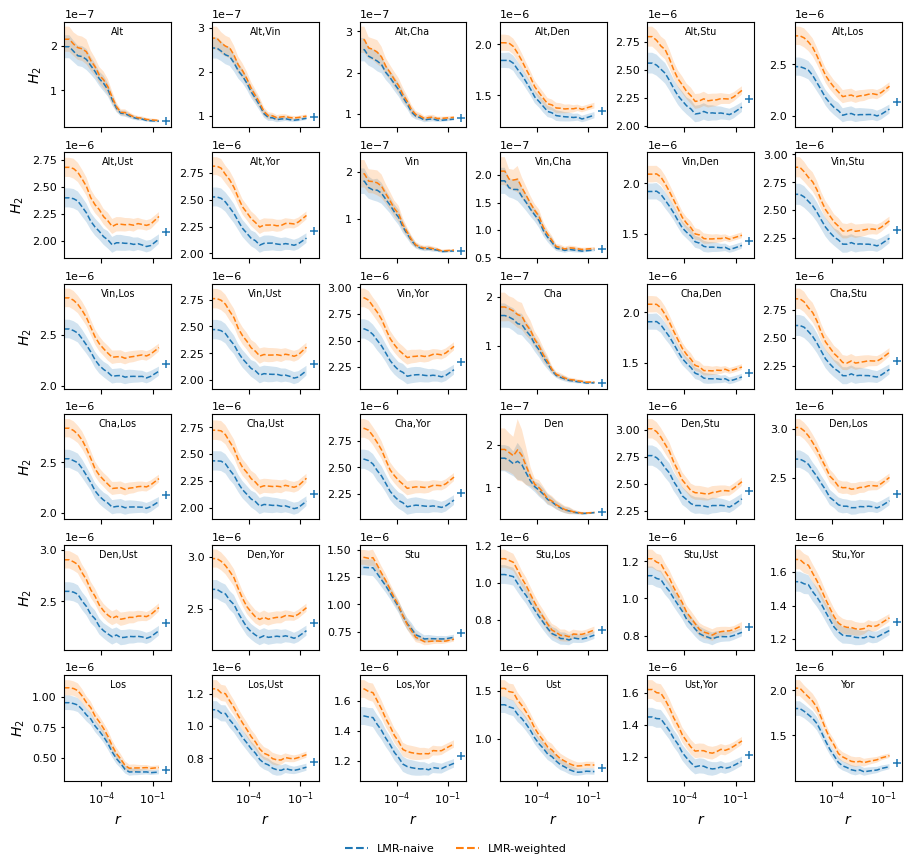

In [8]:
def plot_empirical_weighting_comp_zhou(axs):
    weighted_data_file = "statistics/main/zhou_weighted_stats.pkl"
    naive_data_file = "statistics/main/zhou_naive_stats.pkl"
    weighted_data = dpluspy.inference.load_stats(
        weighted_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    naive_data = dpluspy.inference.load_stats(
        naive_data_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        naive_data, 
        axs, 
        color="tab:blue", 
        alpha=0.2,
        linestyle="--",
        labels=labels, 
        plot_sqrhet=True,
        fill=True,
    )
    plot_stats_on_axs(
        weighted_data, 
        axs,
        color="tab:orange",
        alpha=0.2,
        linestyle="--", 
        labels=None,
        fill=True
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_empirical_weighting_comp_zhou(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", linestyle="--", label=r"LMR-naive"),
    matplotlib.lines.Line2D([], [], color="tab:orange", linestyle="--", label=r"LMR-weighted"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/weighting_comp_zhou.pdf")

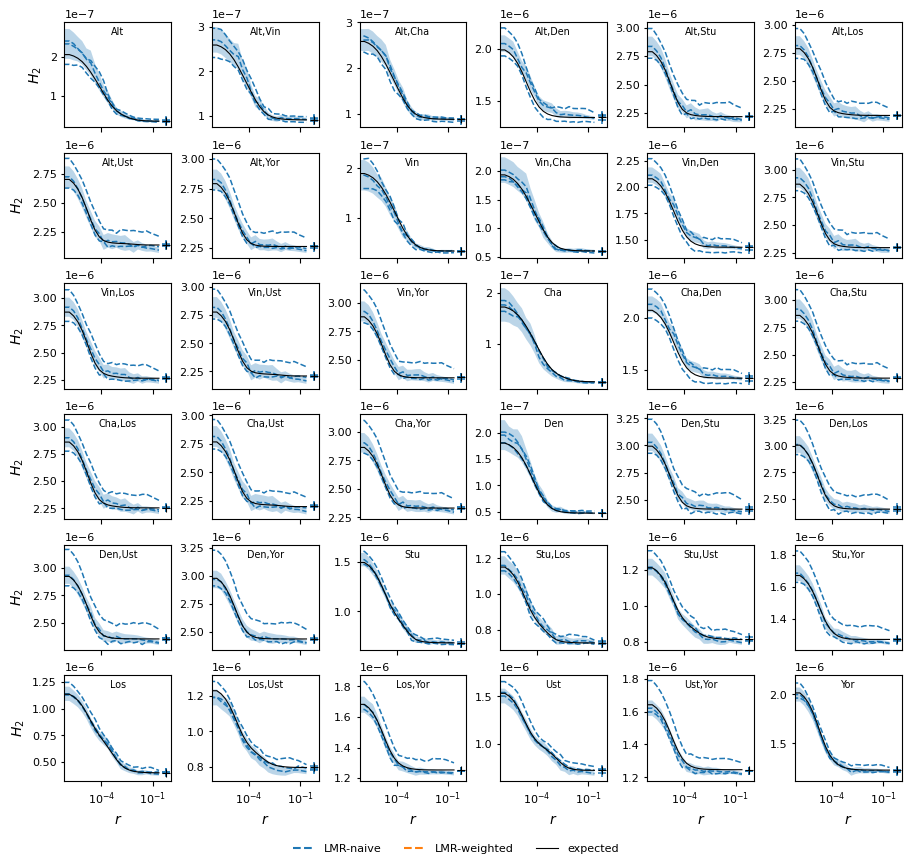

In [7]:
"""
plot simulated model recapitulation
this uses data (with local rate variation) from the mutation_weighting_demo simulation directory.
"""


def plot_sim_weighting_comp(axs):
    naive_file_0 = "simulations/mutation_weighting_demo/extra_trials/unif_rep_0_weighted_stats.pkl"
    naive_file_1 = "simulations/mutation_weighting_demo/extra_trials/unif_rep_1_naive_stats.pkl"
    naive_file_2 = "simulations/mutation_weighting_demo/extra_trials/unif_rep_2_naive_stats.pkl"
    
    naive_data_0 = dpluspy.inference.load_stats(
        naive_file_0, return_dict=True, to_pops=bherer_data["pop_ids"])
    naive_data_1 = dpluspy.inference.load_stats(
        naive_file_1, return_dict=True, to_pops=bherer_data["pop_ids"])
    naive_data_2 = dpluspy.inference.load_stats(
        naive_file_2, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    graph_file = "models/main_models/bherer_full.yaml" 
    model = get_model(graph_file, naive_data_0, u=1.3e-08)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(naive_data_0, axs, color="tab:blue", alpha=0.2,
        linestyle="--", labels=labels, plot_sqrhet=True,)
    plot_stats_on_axs(naive_data_1, axs, color="tab:blue",
        linestyle="--", labels=labels, plot_sqrhet=True, fill=True,)
    plot_stats_on_axs(naive_data_2, axs, color="tab:blue",
        linestyle="--", labels=labels, plot_sqrhet=True,)
    plot_stats_on_axs(
        model, 
        axs,
        color="black", 
        labels=None, 
        plot_sqrhet=True,
        lw=0.8
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_sim_weighting_comp(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", linestyle="--", label=r"LMR-naive"),
    matplotlib.lines.Line2D([], [], color="tab:orange", linestyle="--", label=r"LMR-weighted"),
    matplotlib.lines.Line2D([], [], color="black", linestyle="-", lw=0.8, label="expected"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/sim_recapitulation.pdf")

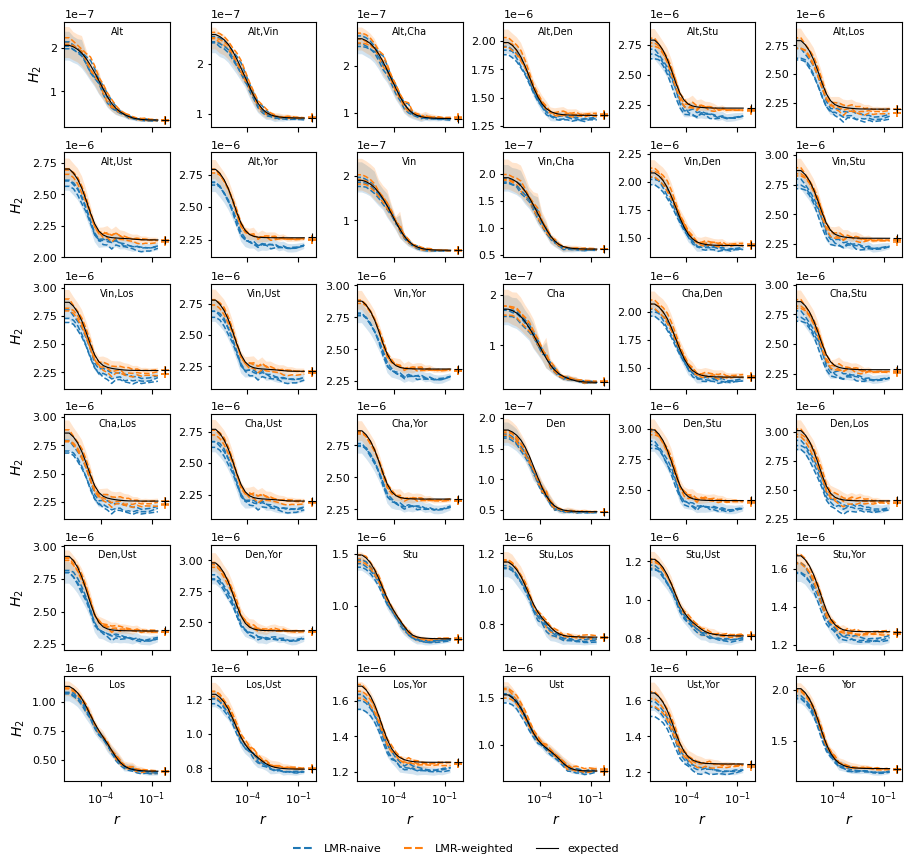

In [23]:
"""
plot weighting simulations
"""


def plot_sim_weighting_comp(axs):
    naive_file_0 = "simulations/mutation_weighting_demo/trials/unif_rep_0_naive_stats.pkl"
    weighted_file_0 = "simulations/mutation_weighting_demo/trials/unif_rep_0_weighted_stats.pkl"
    
    naive_file_1 = "simulations/mutation_weighting_demo/trials/unif_rep_1_naive_stats.pkl"
    weighted_file_1 = "simulations/mutation_weighting_demo/trials/unif_rep_1_weighted_stats.pkl"
    
    naive_file_2 = "simulations/mutation_weighting_demo/trials/unif_rep_2_naive_stats.pkl"
    weighted_file_2 = "simulations/mutation_weighting_demo/trials/unif_rep_2_weighted_stats.pkl"
    
    naive_data_0 = dpluspy.inference.load_stats(
        naive_file_0, return_dict=True, to_pops=bherer_data["pop_ids"])
    weighted_data_0 = dpluspy.inference.load_stats(
        weighted_file_0, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    naive_data_1 = dpluspy.inference.load_stats(
        naive_file_1, return_dict=True, to_pops=bherer_data["pop_ids"])
    weighted_data_1 = dpluspy.inference.load_stats(
        weighted_file_1, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    naive_data_2 = dpluspy.inference.load_stats(
        naive_file_2, return_dict=True, to_pops=bherer_data["pop_ids"])
    weighted_data_2 = dpluspy.inference.load_stats(
        weighted_file_2, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    graph_file = "models/main_models/bherer_full.yaml" 
    model = get_model(graph_file, naive_data_0, u=1.3e-08)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    
    plot_stats_on_axs(naive_data_0, axs, color="tab:blue", alpha=0.2,
        linestyle="--", labels=labels,  fill=True,)
    plot_stats_on_axs(weighted_data_0, axs, color="tab:orange", alpha=0.2,
        linestyle="--", labels=None, fill=True, plot_sqrhet=True,)
    
    plot_stats_on_axs(naive_data_1, axs, color="tab:blue",
        linestyle="--", labels=labels,  fill=False,)
    plot_stats_on_axs(weighted_data_1, axs, color="tab:orange",
        linestyle="--", labels=None, fill=False, plot_sqrhet=True,)
    
    plot_stats_on_axs(naive_data_2, axs, color="tab:blue",
        linestyle="--", labels=labels,  fill=False,)
    plot_stats_on_axs(weighted_data_2, axs, color="tab:orange",
        linestyle="--", labels=None, fill=False, plot_sqrhet=True,)
    
    plot_stats_on_axs(
        model, 
        axs,
        color="black", 
        labels=None,
        lw=0.8,
        plot_sqrhet=True,
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_sim_weighting_comp(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", linestyle="--", label=r"LMR-naive"),
    matplotlib.lines.Line2D([], [], color="tab:orange", linestyle="--", label=r"LMR-weighted"),
    matplotlib.lines.Line2D([], [], color="black", linestyle="-", lw=0.8, label="expected"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/sim_weighting_comp.pdf")

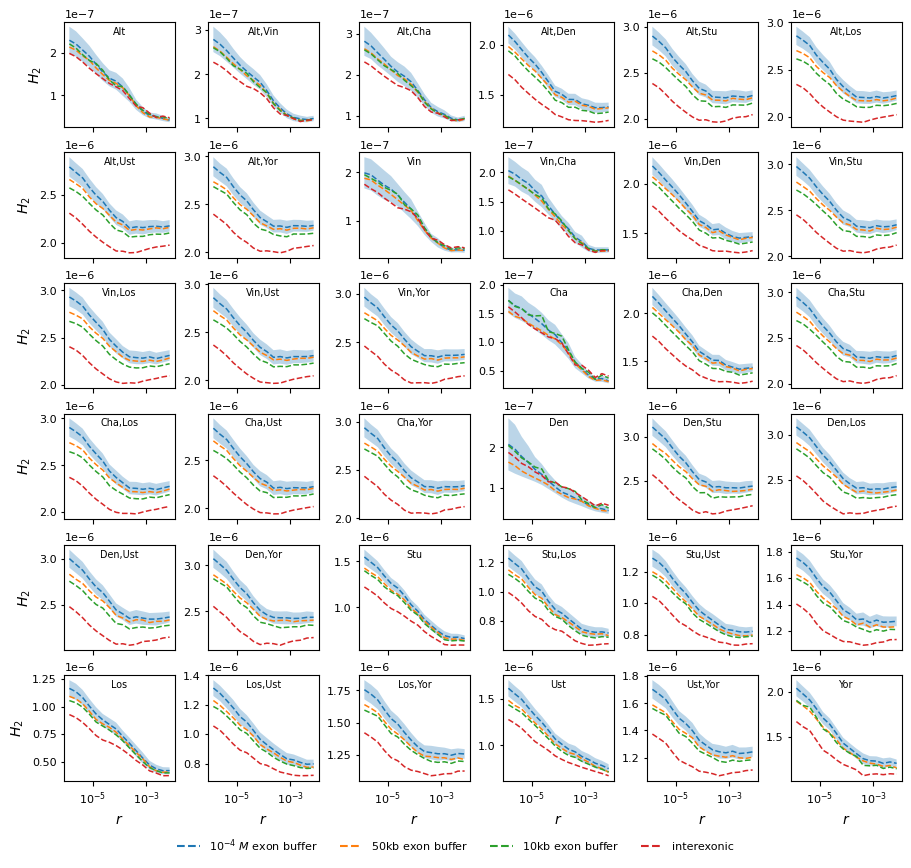

In [31]:
def plot_exon_buffer_comp(axs):
    intergenic_file = "statistics/supplementary/placeholder/stats_intergenic.pkl"
    buffer10_file = "statistics/supplementary/placeholder/stats_10kb_exon_buffer.pkl"
    buffer50_file = "statistics/supplementary/placeholder/stats_50kb_exon_buffer.pkl"
    intergenic_data = dpluspy.inference.load_stats(
        intergenic_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    buffer10_data = dpluspy.inference.load_stats(
        buffer10_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    buffer50_data = dpluspy.inference.load_stats(
        buffer50_file, return_dict=True, to_pops=bherer_data["pop_ids"])
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:blue", 
        linestyle="--",
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(
        buffer50_data, 
        axs,
        color="tab:orange",
        linestyle="--", 
        labels=None
    )
    plot_stats_on_axs(
        buffer10_data, 
        axs,
        color="tab:green",
        linestyle="--", 
        labels=None
    )
    plot_stats_on_axs(
        intergenic_data, 
        axs,
        color="tab:red",
        linestyle="--", 
        labels=None
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_exon_buffer_comp(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", linestyle="--", label="$10^{-4}$ $M$ exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", linestyle="--", label="$50$kb exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", linestyle="--", label="$10$kb exon buffer"),
    matplotlib.lines.Line2D(
        [], [], color="tab:red", label="interexonic", linestyle="--"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.04))
plt.savefig("figures/exon_buffer_comp.pdf")

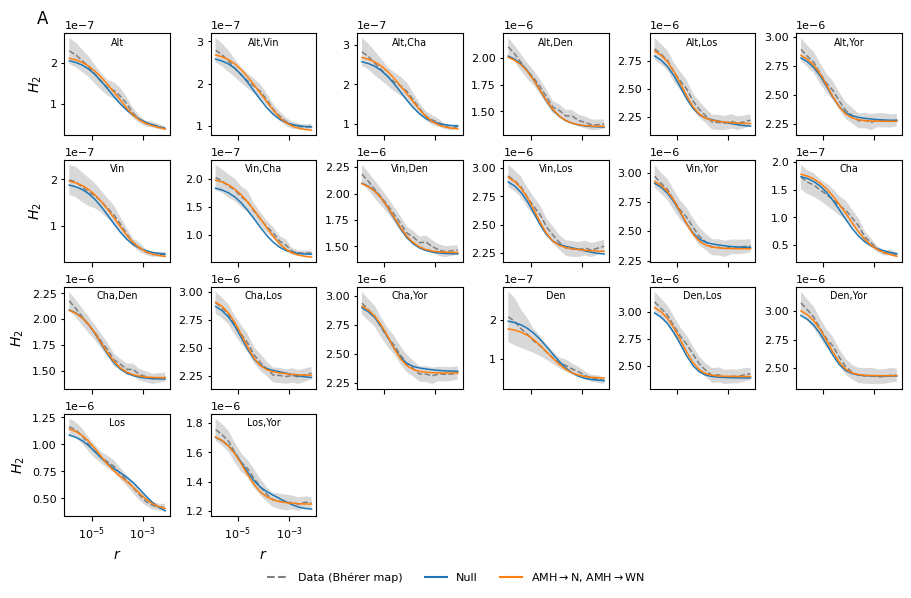

In [5]:
def plot_bherer_amh_nea_models(axs):
    graph_0 = "models/main_models/bherer_amh_nea_no_pulse.yaml"
    graph_1 = "models/main_models/bherer_amh_nea_one_pulse.yaml"
    graph_2 = "models/main_models/bherer_amh_nea_two_pulse.yaml"
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    model_2 = get_model(graph_2, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    # plot_stats_on_axs(model_1, axs, color="tab:orange")
    plot_stats_on_axs(model_2, axs, color="tab:orange")
    return


fig, axs = plt.subplots(
    4, 6, figsize=(9, 5.6), layout="constrained", sharex=1)
plot_bherer_amh_nea_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Null", linestyle="-"),
    # matplotlib.lines.Line2D(
    #    [], [], color="tab:orange", label=r"AMH$\to$N", linestyle="-"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"AMH$\to$N, AMH$\to$WN", linestyle="-"),
]
fig.legend(
    handles=labels, framealpha=0, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat[-4:]:
    ax.remove()
label_ax(axs[0, 0], "A")
plt.savefig("figures/bherer_amh_neanderthal_models.pdf")

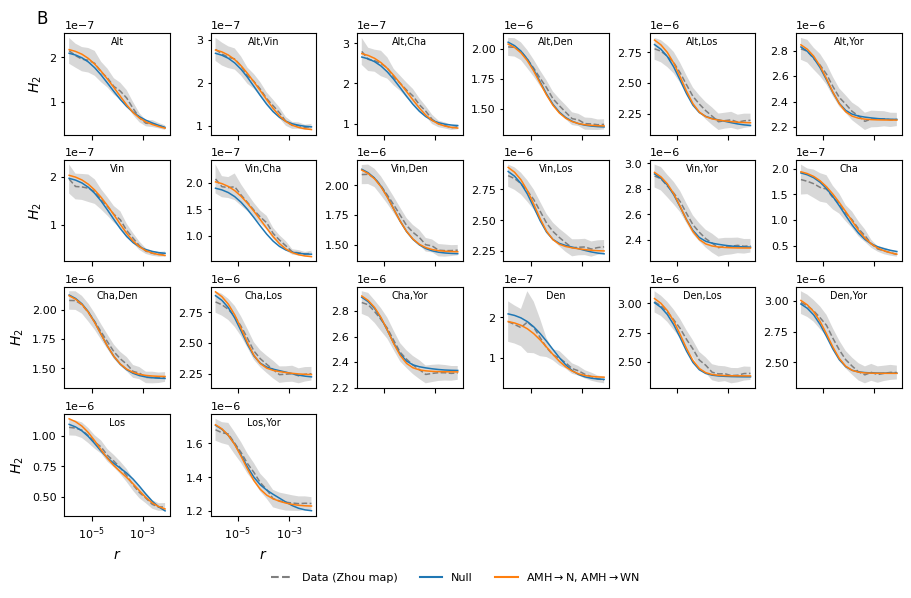

In [4]:
def plot_zhou_amh_nea_models(axs):
    graph_0 = "models/main_models/zhou_amh_nea_no_pulse.yaml"
    graph_1 = "models/main_models/zhou_amh_nea_one_pulse.yaml"
    graph_2 = "models/main_models/zhou_amh_nea_two_pulse.yaml"
    data = dpluspy.inference.load_stats(
        zhou_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    model_2 = get_model(graph_2, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    # plot_stats_on_axs(model_1, axs, color="tab:orange")
    plot_stats_on_axs(model_2, axs, color="tab:orange")
    return


fig, axs = plt.subplots(
    4, 6, figsize=(9, 5.6), layout="constrained", sharex=1)
plot_zhou_amh_nea_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Zhou map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Null", linestyle="-"),
    # matplotlib.lines.Line2D(
    #    [], [], color="tab:orange", label=r"AMH$\to$N", linestyle="-"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"AMH$\to$N, AMH$\to$WN", linestyle="-"),
]
fig.legend(
    handles=labels, framealpha=0, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat[-4:]:
    ax.remove()
label_ax(axs[0, 0], "B")
plt.savefig("figures/zhou_amh_neanderthal_models.pdf")

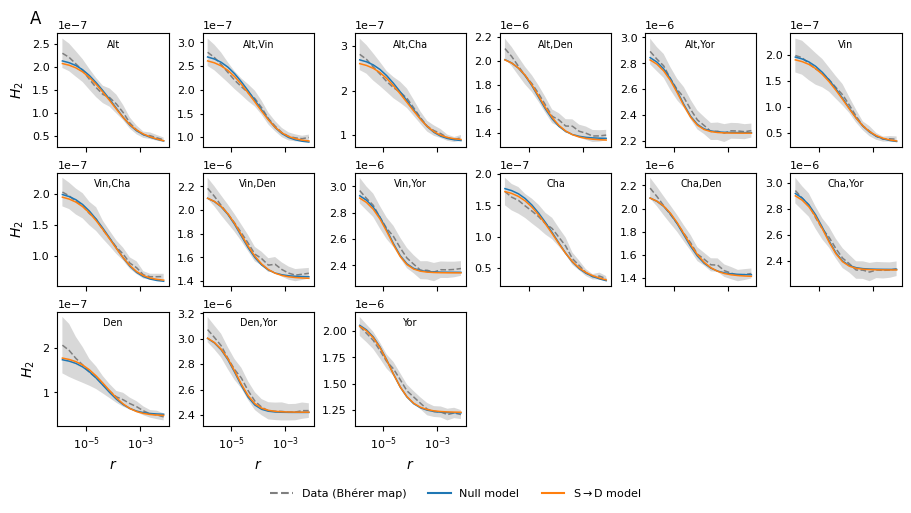

In [77]:
def plot_bherer_sup_den_models(axs):
    graph_0 = "models/main_models/bherer_sup_den_no_pulse.yaml"
    graph_1 = "models/main_models/bherer_sup_den.yaml"
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    return


fig, axs = plt.subplots(3, 6, figsize=(9, 4.7), layout="constrained", 
                        sharex=1)
plot_bherer_sup_den_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label=r"Null model"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"S$\to$D model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
for ax in axs.flat[-3:]:
    ax.remove()
label_ax(axs[0, 0], "A")
plt.savefig("figures/bherer_sup_den_models.pdf")

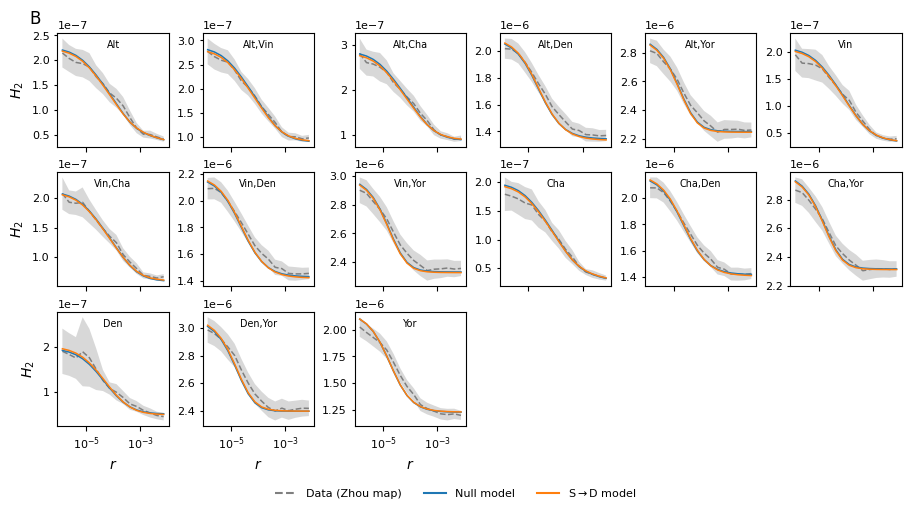

In [78]:
def plot_zhou_sup_den_models(axs):
    graph_0 = "models/main_models/zhou_sup_den_no_pulse.yaml"
    graph_1 = "models/main_models/zhou_sup_den.yaml"
    data = dpluspy.inference.load_stats(
        zhou_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    return


fig, axs = plt.subplots(3, 6, figsize=(9, 4.7), layout="constrained", 
                        sharex=1)
plot_zhou_sup_den_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Zhou map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label=r"Null model"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"S$\to$D model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
for ax in axs.flat[-3:]:
    ax.remove()
label_ax(axs[0, 0], "B")
plt.savefig("figures/zhou_sup_den_models.pdf")

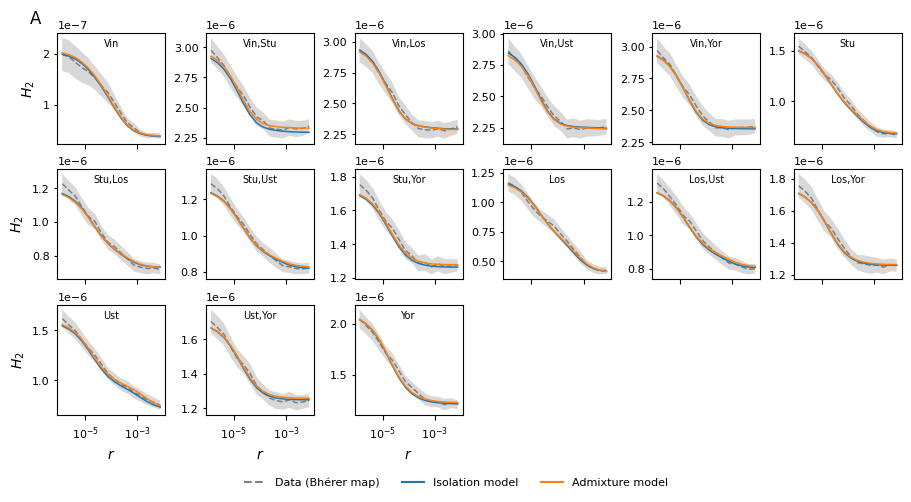

In [83]:
def plot_bherer_amh_models(axs):
    graph_0 = "models/main_models/bherer_los_stu_isolation.yaml"
    graph_1 = "models/main_models/bherer_los_stu_admixture.yaml"
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    return


fig, axs = plt.subplots(
    3, 6, figsize=(9, 4.6), layout="constrained", sharex=1)
plot_bherer_amh_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D([], [], color="tab:blue", label="Isolation model"),
    matplotlib.lines.Line2D([], [], color="tab:orange", label="Admixture model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
for ax in axs.flat[-3:]:
    ax.remove()
label_ax(axs[0, 0], "A")
plt.savefig("figures/bherer_amh_models.pdf")

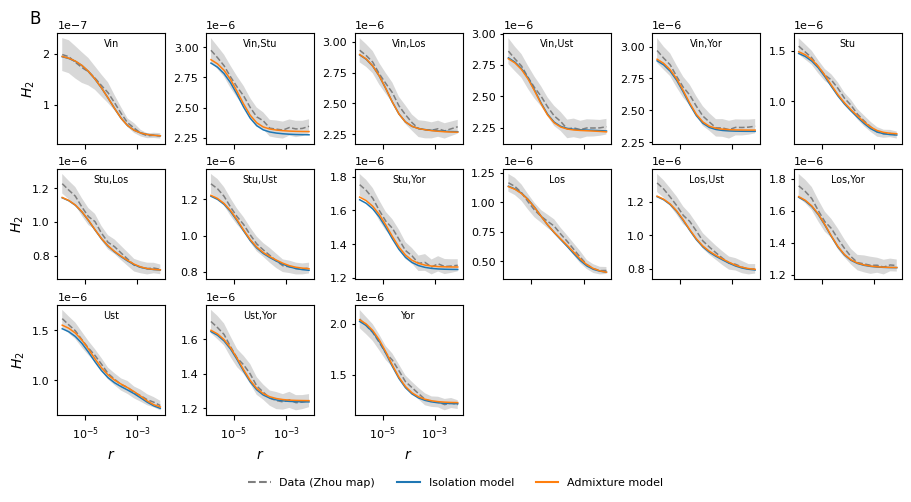

In [86]:
def plot_zhou_amh_models(axs):
    graph_0 = "models/main_models/zhou_los_stu_isolation.yaml"
    graph_1 = "models/main_models/zhou_los_stu_admixture.yaml"
    data = dpluspy.inference.load_stats(
        bherer_data_file, graph=graph_0, return_dict=True)
    model_0 = get_model(graph_0, data)
    model_1 = get_model(graph_1, data)
    labels = [x[:3] for x in data["pop_ids"]]
    plot_stats_on_axs(
        data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    return


fig, axs = plt.subplots(
    3, 6, figsize=(9, 4.6), layout="constrained", sharex=1)
plot_zhou_amh_models(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Zhou map)", linestyle="--"),
    matplotlib.lines.Line2D([], [], color="tab:blue", label="Isolation model"),
    matplotlib.lines.Line2D([], [], color="tab:orange", label="Admixture model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.07))
for ax in axs.flat[-3:]:
    ax.remove()
label_ax(axs[0, 0], "B")
plt.savefig("figures/zhou_amh_models.pdf")

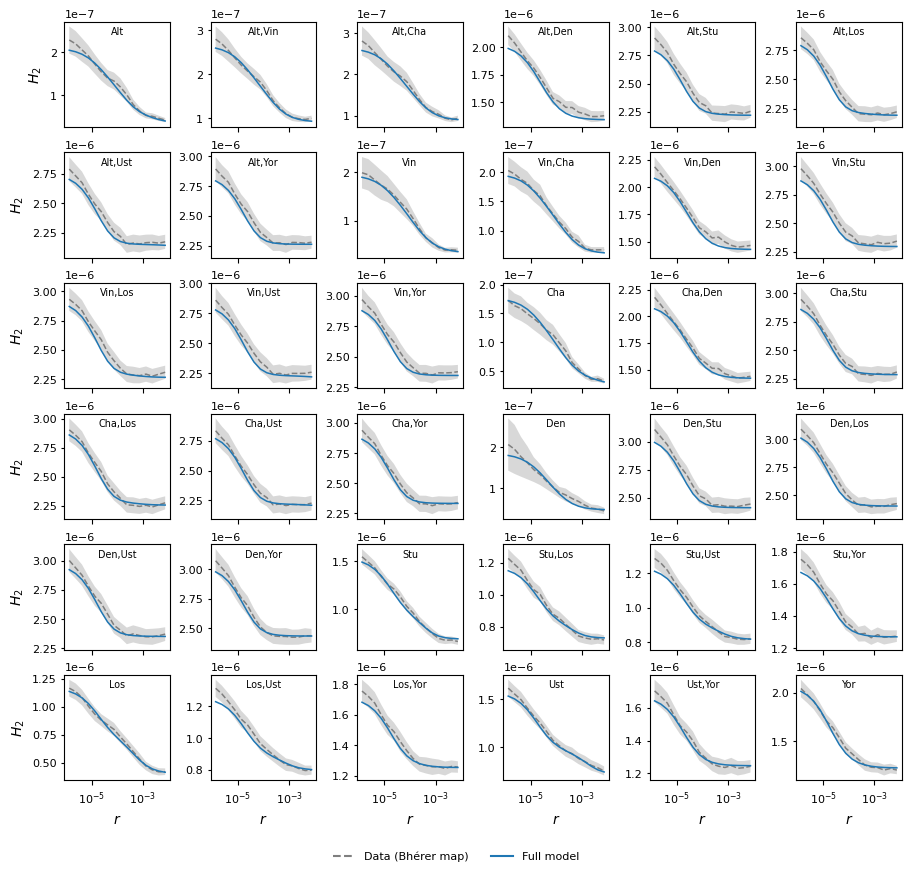

In [46]:
def plot_full_model_bherer(axs):
    graph = "models/main_models/bherer_full.yaml"
    model = get_model(graph, bherer_data)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model, axs, color="tab:blue")
    return

fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_full_model_bherer(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/bherer_full_model.pdf")

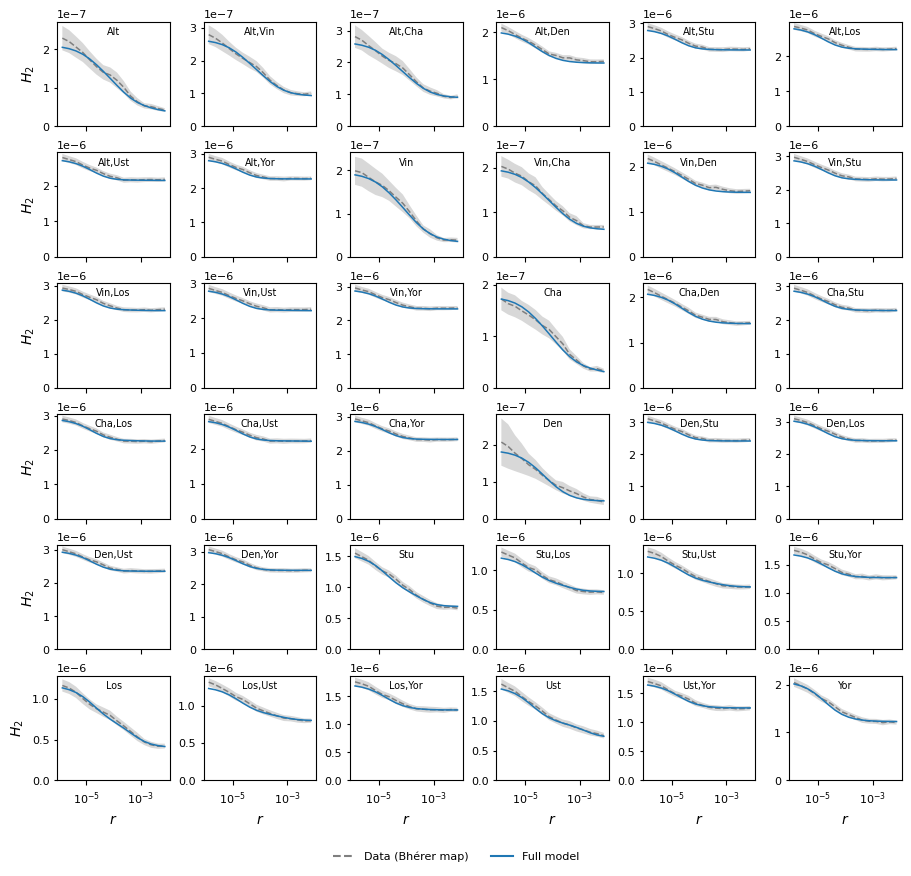

In [6]:
def plot_full_model_bherer_y0(axs):
    graph = "models/main_models/bherer_full.yaml"
    model = get_model(graph, bherer_data)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model, axs, color="tab:blue")
    for ax in axs.flat:
        ax.set_ylim(0,)
    return

fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_full_model_bherer_y0(axs)
labels = [matplotlib.lines.Line2D([], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D([], [], color="tab:blue", label="Full model"),]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/bherer_full_model_ylim0.pdf")

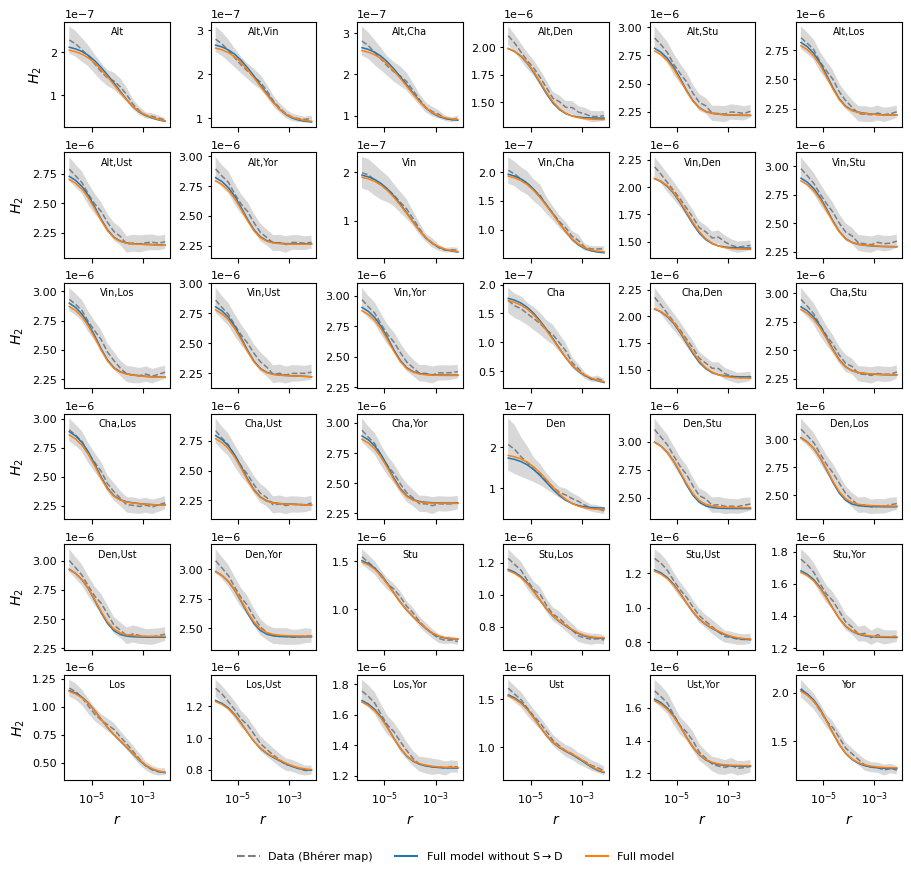

In [87]:
def plot_full_model_without_sup_den(axs):
    graph_0 = "models/main_models/bherer_full_without_sup_den.yaml"
    graph_1 = "models/main_models/bherer_full.yaml"
    model_0 = get_model(graph_0, bherer_data)
    model_1 = get_model(graph_1, bherer_data)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_full_model_without_sup_den(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label=r"Full model without S$\to$D"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/bherer_full_model_without_sup_den.pdf")

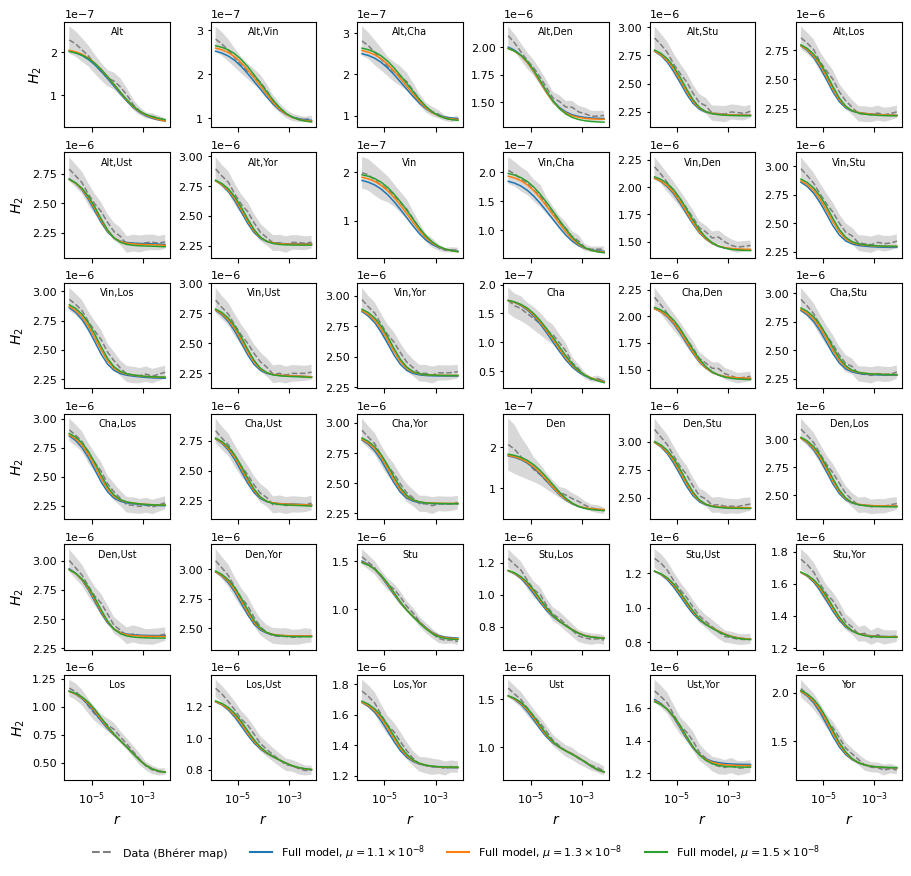

In [97]:
def plot_full_model_without_sup_den(axs):
    graph_0 = "models/main_models/bherer_full_slow_mutation.yaml"
    graph_1 = "models/main_models/bherer_full.yaml"
    graph_2 = "models/main_models/bherer_full_fast_mutation.yaml"
    model_0 = get_model(graph_0, bherer_data, u=1.1e-8)
    model_1 = get_model(graph_1, bherer_data)
    model_2 = get_model(graph_2, bherer_data, u=1.5e-8)
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    plot_stats_on_axs(
        bherer_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model_0, axs, color="tab:blue")
    plot_stats_on_axs(model_1, axs, color="tab:orange")
    plot_stats_on_axs(model_2, axs, color="tab:green")
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_full_model_without_sup_den(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Bhérer map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label=r"Full model, $\mu=1.1\times10^{-8}$"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"Full model, $\mu=1.3\times10^{-8}$"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label=r"Full model, $\mu=1.5\times10^{-8}$"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/bherer_full_model_u_comp.pdf")

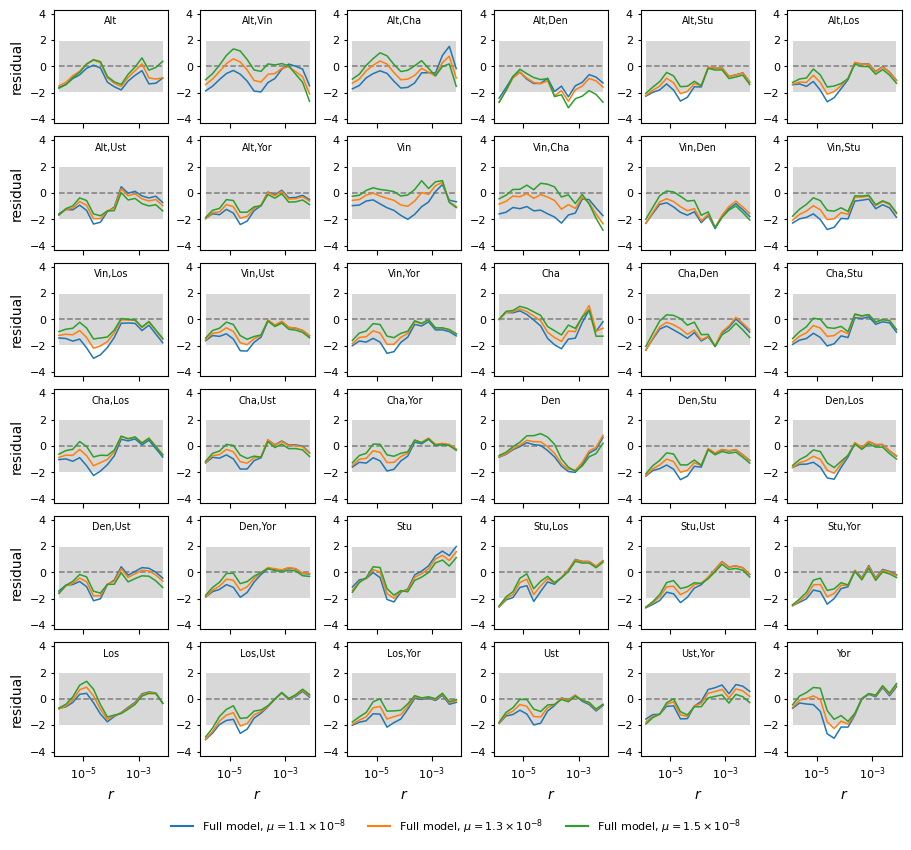

In [142]:
def plot_residuals_slow_fast_u(axs):
    graph_0 = "models/main_models/bherer_full_slow_mutation.yaml"
    graph_1 = "models/main_models/bherer_full.yaml"
    graph_2 = "models/main_models/bherer_full_fast_mutation.yaml"
    model_0 = get_model(graph_0, bherer_data, u=1.1e-8)
    model_1 = get_model(graph_1, bherer_data)
    model_2 = get_model(graph_2, bherer_data, u=1.5e-8)
    residuals_0 = compute_residuals(bherer_data, model_0["means"])
    plot_me_0 = {
        "means": residuals_0, "bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    residuals_1 = compute_residuals(bherer_data, model_1["means"])
    plot_me_1 = {
        "means": residuals_1, "bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    residuals_2 = compute_residuals(bherer_data, model_2["means"])
    plot_me_2 = {
        "means": residuals_2, "bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    fake_data = {"bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in bherer_data["means"]]
    fake_data["varcovs"] = [np.ones(v.shape) for v in bherer_data["varcovs"]]

    plot_stats_on_axs(
        fake_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(plot_me_0, axs, color="tab:blue")
    plot_stats_on_axs(plot_me_1, axs, color="tab:orange")
    plot_stats_on_axs(plot_me_2, axs, color="tab:green", ylabel="residual")
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8), layout="constrained", sharex=1)
plot_residuals_slow_fast_u(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label=r"Full model, $\mu=1.1\times10^{-8}$"),
    matplotlib.lines.Line2D(
        [], [], color="tab:orange", label=r"Full model, $\mu=1.3\times10^{-8}$"),
    matplotlib.lines.Line2D(
        [], [], color="tab:green", label=r"Full model, $\mu=1.5\times10^{-8}$"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=3,
           bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat:
    ax.set_ylim(-4.3, 4.3)
plt.savefig("figures/full_residuals_u_comp.pdf")

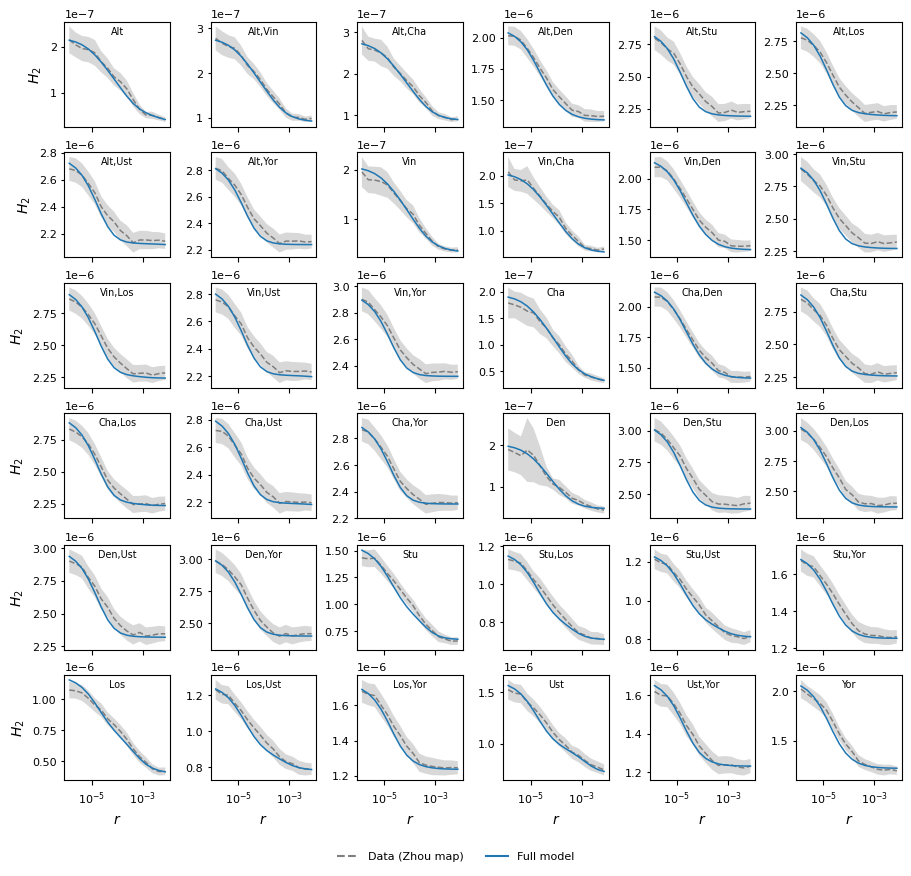

In [48]:
def plot_full_model_zhou(axs):
    graph = "models/main_models/zhou_full.yaml"
    model = get_model(graph, zhou_data)
    labels = [x[:3] for x in zhou_data["pop_ids"]]
    plot_stats_on_axs(
        zhou_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(model, axs, color="tab:blue")
    return

fig, axs = plt.subplots(6, 6, figsize=(9, 8.25), layout="constrained", sharex=1)
plot_full_model_zhou(axs)
labels = [
    matplotlib.lines.Line2D(
        [], [], color="tab:grey", label="Data (Zhou map)", linestyle="--"),
    matplotlib.lines.Line2D(
        [], [], color="tab:blue", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/zhou_full_model.pdf")

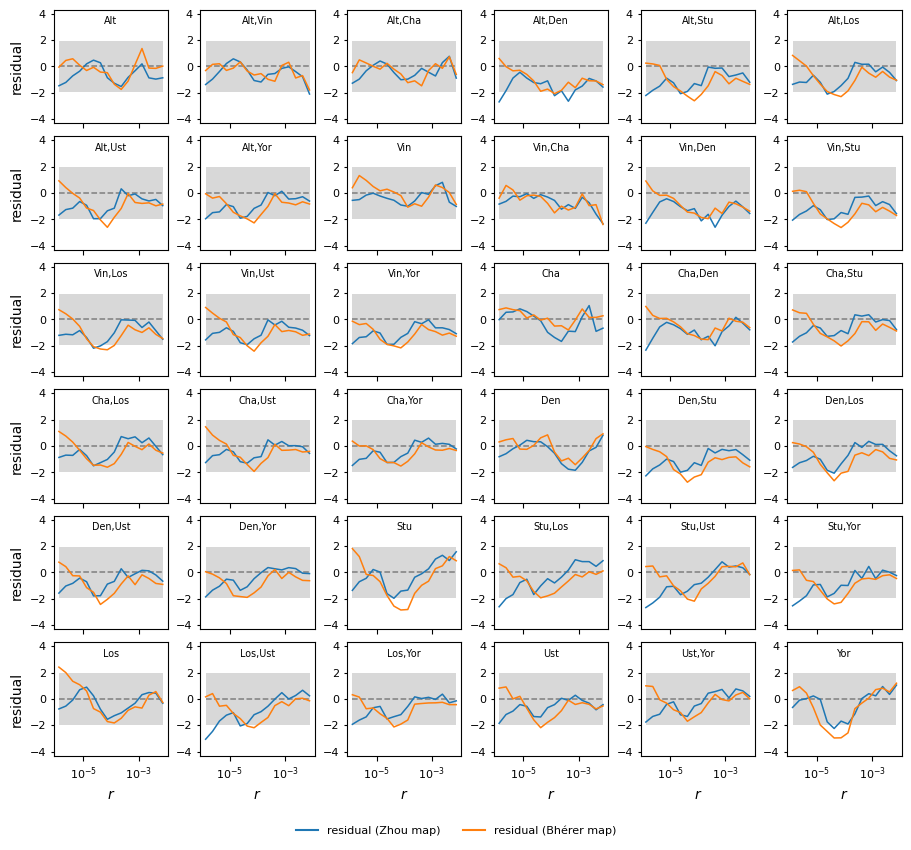

In [153]:
def plot_full_model_residuals(axs):
    graph_bherer = "models/main_models/bherer_full.yaml"
    bherer_model = get_model(graph_bherer, bherer_data)["means"]
    bherer_residuals = compute_residuals(bherer_data, bherer_model)
    plot_me_bherer = {"means": bherer_residuals, "bins": bherer_data["bins"],
                      "pop_ids": bherer_data["pop_ids"]}
    graph_zhou = "models/main_models/zhou_full.yaml"
    zhou_model = get_model(graph_zhou, zhou_data)["means"]
    zhou_residuals = compute_residuals(zhou_data, zhou_model)
    plot_me_zhou = {"means": zhou_residuals, "bins": zhou_data["bins"], 
                    "pop_ids": zhou_data["pop_ids"]}
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    fake_data = {"bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in bherer_data["means"]]
    fake_data["varcovs"] = [np.ones(v.shape) for v in bherer_data["varcovs"]]

    plot_stats_on_axs(
        fake_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(plot_me_bherer, axs, color="tab:blue")
    plot_stats_on_axs(
        plot_me_zhou,
        axs,
        color="tab:orange",
        ylabel="residual"
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8), layout="constrained", sharex=1)
plot_full_model_residuals(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", label="residual (Zhou map)"),
    matplotlib.lines.Line2D([], [], color="tab:orange", label="residual (Bhérer map)"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat:
    ax.set_ylim(-4.3, 4.3)
plt.savefig("figures/full_model_residuals.pdf")

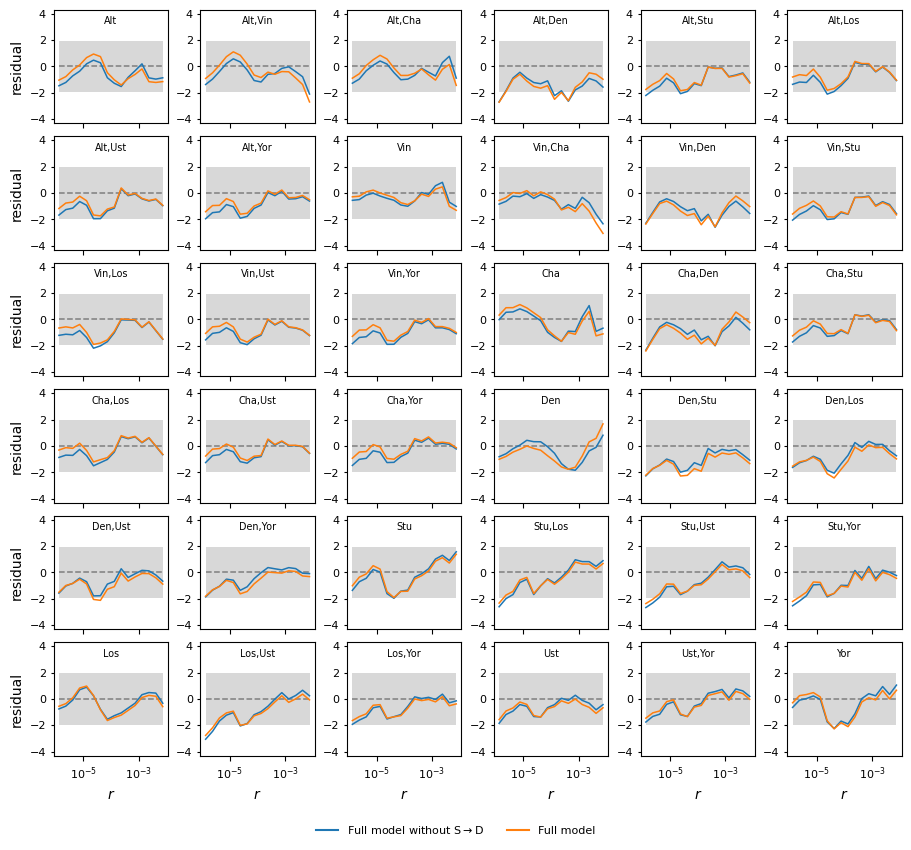

In [154]:
def plot_full_model_without_sup_den_residuals(axs):
    graph_0 = "models/main_models/bherer_full.yaml"
    model_0 = get_model(graph_0, bherer_data)["means"]
    residuals_0 = compute_residuals(bherer_data, model_0)
    plot_me_0 = {"means": residuals_0, "bins": bherer_data["bins"],
                      "pop_ids": bherer_data["pop_ids"]}
    graph_1 = "models/main_models/bherer_full_without_sup_den.yaml"
    model_1 = get_model(graph_1, bherer_data)["means"]
    residuals_1 = compute_residuals(bherer_data, model_1)
    plot_me_1 = {"means": residuals_1, "bins": bherer_data["bins"],
                      "pop_ids": bherer_data["pop_ids"]}
    
    labels = [x[:3] for x in bherer_data["pop_ids"]]
    fake_data = {"bins": bherer_data["bins"], "pop_ids": bherer_data["pop_ids"]}
    fake_data["means"] = [np.zeros(m.shape) for m in bherer_data["means"]]
    fake_data["varcovs"] = [np.ones(v.shape) for v in bherer_data["varcovs"]]

    plot_stats_on_axs(
        fake_data, 
        axs, 
        color="tab:grey", 
        linestyle="--", 
        labels=labels, 
        fill=True
    )
    plot_stats_on_axs(plot_me_0, axs, color="tab:blue")
    plot_stats_on_axs(plot_me_1, axs, color="tab:orange", ylabel="residual"
    )
    return


fig, axs = plt.subplots(6, 6, figsize=(9, 8), layout="constrained", sharex=1)
plot_full_model_without_sup_den_residuals(axs)
labels = [
    matplotlib.lines.Line2D([], [], color="tab:blue", label=r"Full model without S$\to$D"),
    matplotlib.lines.Line2D([], [], color="tab:orange", label="Full model"),
]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2,
           bbox_to_anchor=(0.5, -0.05))
for ax in axs.flat:
    ax.set_ylim(-4.3, 4.3)
plt.savefig("figures/full_model_without_sup_den_residuals.pdf")

In [3]:
"""
Predicting IICR curves. This takes a few minutes
"""


def send_end_times_to_zero(graph, targets):
    builder = graph.asdict()
    for deme in builder["demes"]:
        if deme["name"] in targets:
            deme["epochs"][-1]["end_time"] = 0
    builder = demes.Builder.fromdict(builder)
    return builder.resolve()


def compute_icr(graph, times, samples):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(times, samples)
    return rates


def compute_rccr(graph, times, sample0, sample1):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates00, _ = debug.coalescence_rate_trajectory(ts, {sample0: 2})
    rates11, _ = debug.coalescence_rate_trajectory(ts, {sample1: 2})
    rates12, _ = debug.coalescence_rate_trajectory(ts, {sample0: 1, sample1: 1})
    return traj


_icr_cache = {}

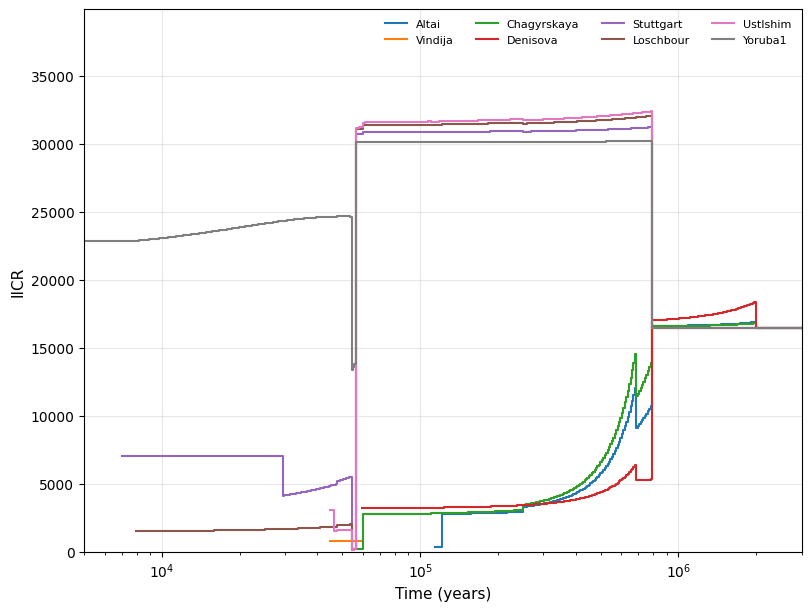

In [4]:
sample_times = {
    "Altai": 1.15e5,
    "Vindija": 4.5e4,
    "Chagyrskaya": 5.5e4,
    "Denisova": 6e4,
    "Stuttgart": 7e3, 
    "Loschbour": 8e3,
    "UstIshim": 4.5e4,
    "Yoruba1": 0
}

samples = list(sample_times.keys())


graph = demes.load("models/main_models/bherer_full.yaml")
zeroed_graph = send_end_times_to_zero(graph, samples)
demog = msprime.Demography.from_demes(zeroed_graph)
debug = demog.debug()
times_in_years = np.logspace(np.log10(5e3), np.log10(3e6), 500)
times = times_in_years / 29
icrs = {}

for sample in samples:
    if sample in _icr_cache:
        icrs[sample] = _icr_cache[sample]
    else:
        sample_cfg = {sample: 2}
        icr, _ = debug.coalescence_rate_trajectory(times, sample_cfg)
        min_time = sample_times[sample]
        icr[times_in_years < min_time] = np.nan
        _icr_cache[sample] = icr
        icrs[sample] = icr


colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray"
]


fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
ax.grid(axis="both", alpha=0.3)
for sample, color in zip(samples, colors):
    iicr = 1 / (2 * icrs[sample])
    ax.step(times_in_years, iicr, label=sample, lw=1.5, color=color)
ax.legend(framealpha=0, ncols=4)
ax.set_ylim(0, 3.99e4)
ax.set_xlim(5e3, times_in_years[-1])
ax.set_xscale("log")
ax.set_xlabel("Time (years)")
ax.set_ylabel("IICR")
plt.savefig("figures/predicted_psmc.pdf")

In [146]:
"""
H and F-statistics.
"""
    

def compute_F2(Hs):
    stats = dpluspy.datastructures.DPlusStats([Hs], pop_ids=list(range(8)))
    F2 = []
    for ii in range(8):
        for jj in range(ii + 1, 8):
            F2.append(stats.F2(ii, jj))
    return np.array(F2)   


def get_block_F2():
    input_fname = "statistics/main/bherer_weighted_raw_sums.pkl"
    with open(input_fname, "rb") as fin:
        raw_data = pickle.load(fin)
    block_F2s = {}
    for block in raw_data:
        block_L = raw_data[block]["denoms"][-1]
        block_H = raw_data[block]["sums"][-1]
        Hs = block_H / block_L
        Hs = dpluspy.bootstrapping.subset_means(
            [Hs], raw_data[block]["pop_ids"], bherer_data["pop_ids"])[0]
        block_F2 = compute_F2(Hs)
        block_F2s[block] = {"sums": [block_F2 * block_L], "denoms": [block_L]}
    return block_F2s


block_F2s = get_block_F2()
samples = dpluspy.bootstrapping.get_bootstrap_reps(block_F2s)
var_F2 = np.var(samples, axis=0)[0]

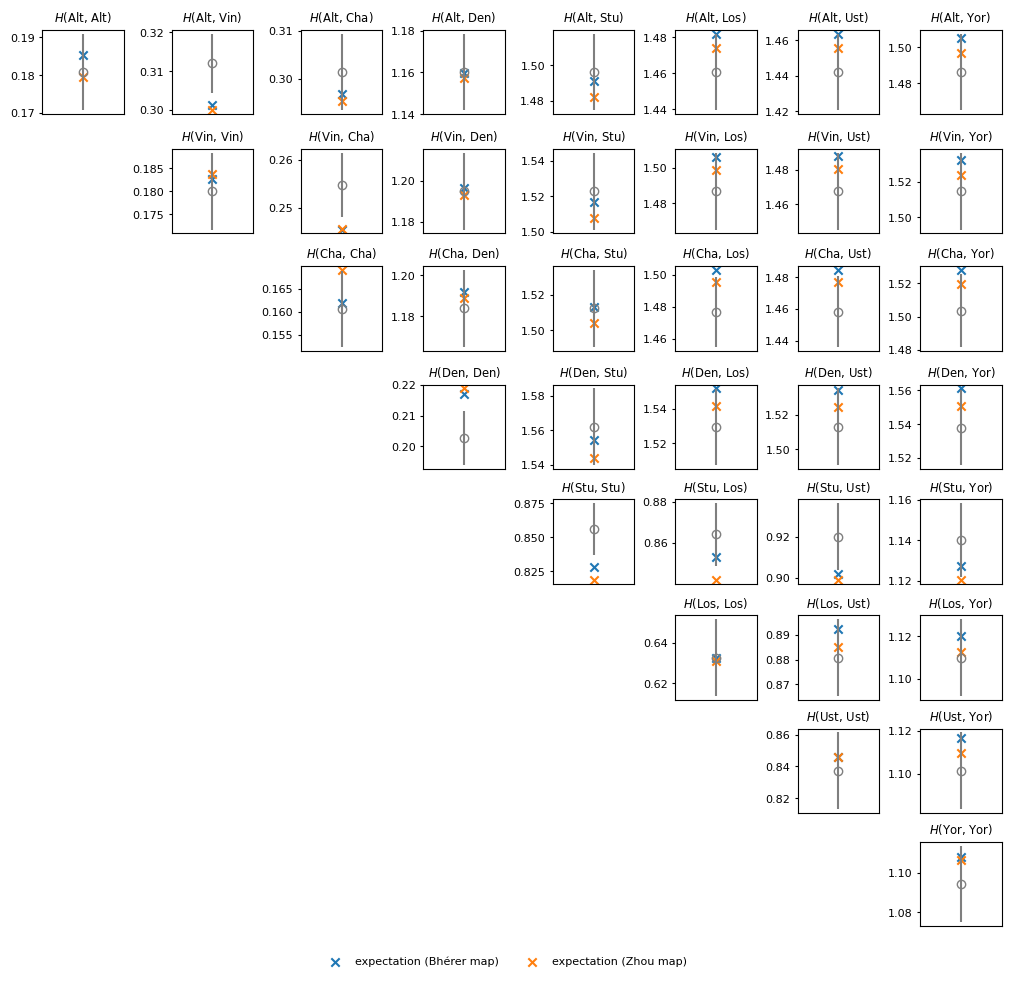

In [147]:
def plot_H_stats(axs):
    graph_bherer = "models/main_models/bherer_full.yaml"
    model_bherer = get_model(graph_bherer, bherer_data)
    bherer_EH = model_bherer["means"][-1] * 1e3

    graph_zhou = "models/main_models/zhou_full.yaml"
    model_zhou = get_model(graph_zhou, zhou_data)
    zhou_EH = model_zhou["means"][-1] * 1e3
    
    pop_ids = bherer_data["pop_ids"]
    mean_H = bherer_data["means"][-1] * 1e3
    cov_H = bherer_data["varcovs"][-1]
    std_H = np.diagonal(cov_H) ** 0.5 * 1e3
    k0 = 0
    k1 = 0
    for ii in range(len(pop_ids)):
        for jj in range(len(pop_ids)):
            if jj >= ii:
                axs[ii, jj].set_title(f"$H$({pop_ids[ii][:3]}, {pop_ids[jj][:3]})", fontsize="small")
                axs[ii, jj].errorbar([0], [mean_H[k0]], yerr=[std_H[k0] * 1.96], marker="o", color="tab:grey",
                                    markerfacecolor="none")
                axs[ii, jj].scatter([0], [bherer_EH[k0]], color="tab:blue", marker="x") 
                axs[ii, jj].scatter([0], [zhou_EH[k0]], color="tab:orange", marker="x") 
                k0 += 1
                
            else:
                axs[ii, jj].remove()
                
    for ax in axs.flat:
        ax.set_xticks([])
    return 

fig, axs = plt.subplots(8, 8, figsize=(10, 9.25), layout="constrained")
plot_H_stats(axs)
mb = axs[0, 0].scatter([], [],  color="tab:blue", marker="x", label="expectation (Bhérer map)")
mz = axs[0, 0].scatter([], [],  color="tab:orange", marker="x", label="expectation (Zhou map)")
labels = [mb, mz]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/predicted_H_depr.pdf")

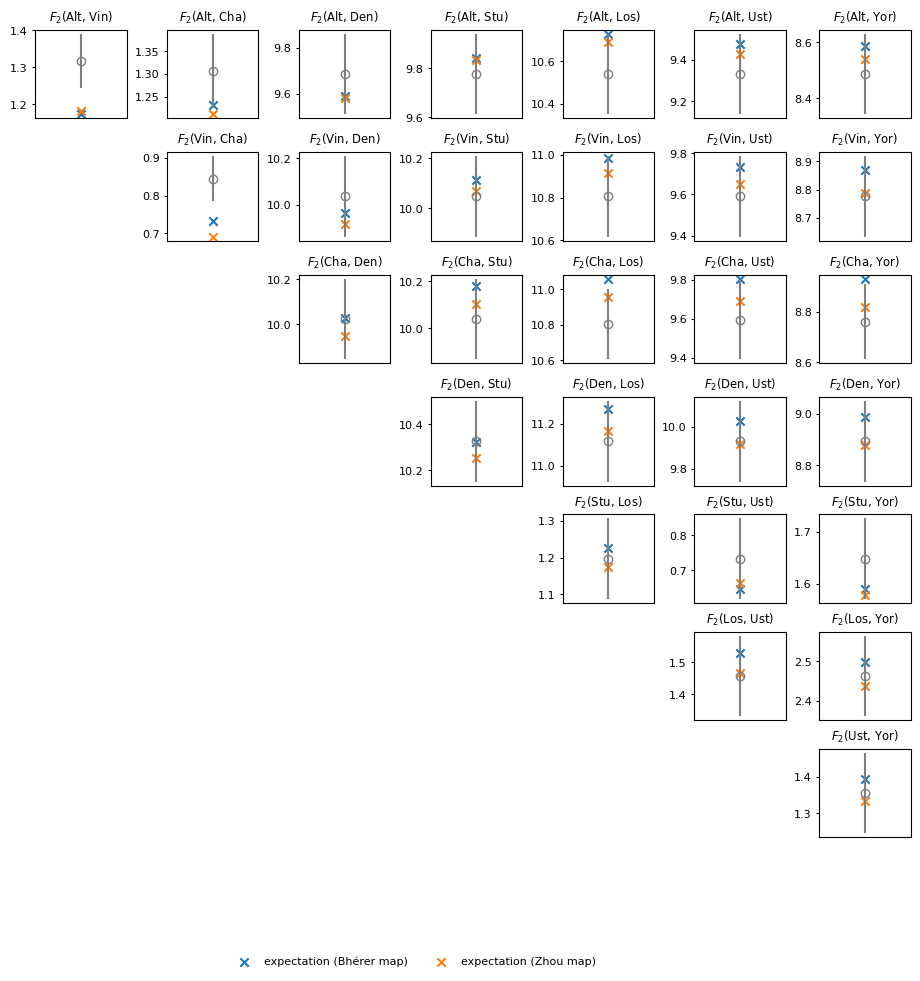

In [148]:
def plot_F2_stats(axs):
    graph_bherer = "models/main_models/bherer_full.yaml"
    model_bherer = get_model(graph_bherer, bherer_data)
    bherer_EF2 = compute_F2(model_bherer["means"][-1]) * 1e4

    graph_zhou = "models/main_models/zhou_full.yaml"
    model_zhou = get_model(graph_zhou, zhou_data)
    zhou_EF2 = compute_F2(model_zhou["means"][-1]) * 1e4
    
    pop_ids = bherer_data["pop_ids"]
    mean_F2 = compute_F2(bherer_data["means"][-1]) * 1e4
    std_F2 = var_F2 ** 0.5 * 1e4
    k = 0
    for ii in range(len(pop_ids)):
        for jj in range(len(pop_ids)):
            if jj > ii:
                # k1 indexes pairs of *distinct* populations
                axs[ii, jj].set_title(f"$F_2$({pop_ids[ii][:3]}, {pop_ids[jj][:3]})", fontsize="small")
                axs[ii, jj].errorbar([0], [mean_F2[k]], yerr=[std_F2[k] * 1.96], marker="o", color="tab:grey",
                                    markerfacecolor="none")
                axs[ii, jj].scatter([0], [bherer_EF2[k]], color="tab:blue", marker="x") 
                axs[ii, jj].scatter([0], [zhou_EF2[k]], color="tab:orange", marker="x") 
                k += 1
            else:
                axs[ii, jj].remove()
                
    for ax in axs.flat:
        ax.set_xticks([])
    return 

fig, axs = plt.subplots(8, 8, figsize=(10, 9.25), layout="constrained")
plot_F2_stats(axs)
mb = axs[0, 0].scatter([], [],  color="tab:blue", marker="x", label="expectation (Bhérer map)")
mz = axs[0, 0].scatter([], [],  color="tab:orange", marker="x", label="expectation (Zhou map)")
labels = [mb, mz]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=2, bbox_to_anchor=(0.5, -0.05))
plt.savefig("figures/predicted_F2_depr.pdf")

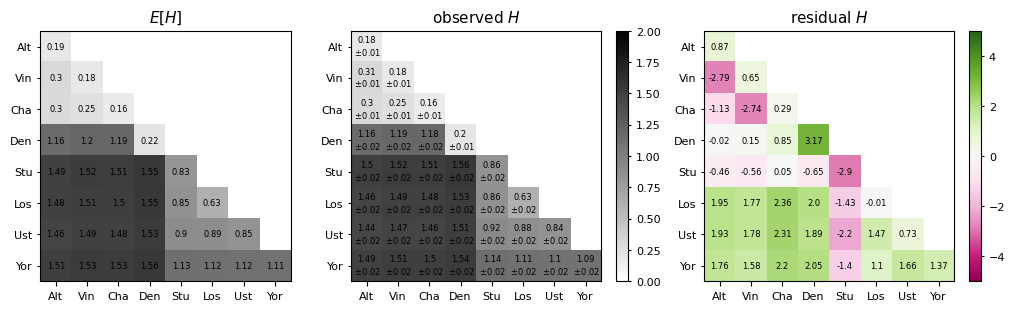

In [237]:
"""
H heatmaps
"""


def get_H_arrs(data):
    """
    `data` is a dictionary of statistics
    """
    n_pops = len(data["pop_ids"])
    means = np.full((n_pops, n_pops), np.nan)
    idx = 0
    for ii in range(n_pops):
        for jj in range(ii, n_pops):
            means[jj, ii] = data["means"][-1][idx]
            idx += 1
    if "varcovs" in data:
        idx = 0
        stds = np.full((n_pops, n_pops), np.nan)
        for ii in range(n_pops):
            for jj in range(ii, n_pops):
                stds[jj, ii] = data["varcovs"][-1][idx, idx] ** 0.5
                idx += 1
        ret = (means, stds)
    else: 
        ret = means
    return ret


bherer_graph = "models/main_models/bherer_full.yaml"
bherer_model = get_model(bherer_graph, bherer_data)
E_H_arr = get_H_arrs(bherer_model)
H_arr, H_stds = get_H_arrs(bherer_data)
pop_ids = bherer_data["pop_ids"]
scale = 1e3
E_H_arr *= scale
H_arr *= scale
H_stds *= scale
residuals = (E_H_arr - H_arr) / H_stds


fig, axs = plt.subplot_mosaic("ABC", figsize=(10, 3), layout="constrained")
cmap = "binary"

im = axs["A"].imshow(E_H_arr, cmap=cmap, vmin=0, vmax=2)
axs["A"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_title("$E[H]$")

im = axs["B"].imshow(H_arr, cmap=cmap, vmin=0, vmax=2)
fig.colorbar(im)
axs["B"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_title("observed $H$")

im = axs["C"].imshow(residuals, cmap="PiYG", vmin=-5, vmax=5)
fig.colorbar(im)
axs["C"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_title("residual $H$")


def annotate(ax, data, stds=None):
    for ii in range(len(pop_ids)):
        for jj in range(ii, len(pop_ids)):
            if stds is None:
                txt = np.round(data[jj, ii], 2)
            else:        
                xx = np.round(data[jj, ii], 2)
                ci = np.round(stds[jj, ii] * 1.96, 2)
                txt = f"{xx}\n $\\pm${ci}"
            ax.text(ii, jj, txt, ha="center", va="center", color="black", size=6)
    return


annotate(axs["A"], E_H_arr)
annotate(axs["B"], H_arr, stds=H_stds)
annotate(axs["C"], residuals)

plt.savefig("figures/bherer_predicted_H.pdf")

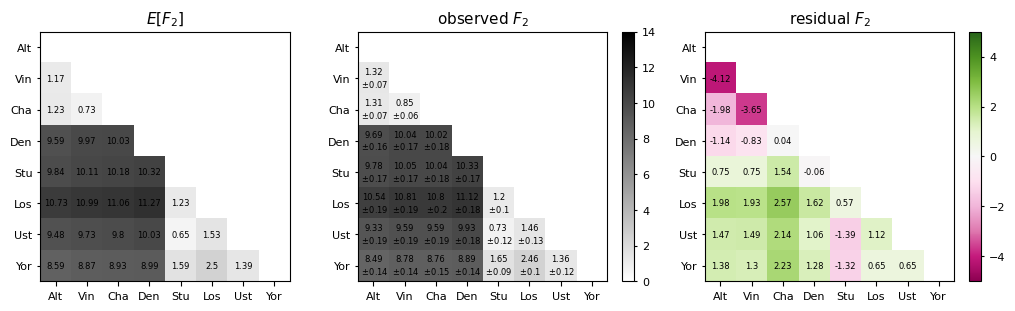

In [236]:
"""
F2 heatmap: Bherer dataset
"""


def compute_F2(Hs):
    stats = dpluspy.datastructures.DPlusStats([Hs], pop_ids=list(range(8)))
    F2 = []
    for ii in range(8):
        for jj in range(ii + 1, 8):
            F2.append(stats.F2(ii, jj))
    return np.array(F2)   


def get_block_F2(input_fname):
    with open(input_fname, "rb") as fin:
        raw_data = pickle.load(fin)
    block_F2s = {}
    for block in raw_data:
        block_L = raw_data[block]["denoms"][-1]
        block_H = raw_data[block]["sums"][-1]
        Hs = block_H / block_L
        Hs = dpluspy.bootstrapping.subset_means(
            [Hs], raw_data[block]["pop_ids"], bherer_data["pop_ids"])[0]
        block_F2 = compute_F2(Hs)
        block_F2s[block] = {"sums": [block_F2 * block_L], "denoms": [block_L]}
    return block_F2s


def get_F2_matrix(data, pop_ids):
    """
    turn a flat array of F2s into a 2dim array.
    """
    n_pops = len(pop_ids)
    matrix = np.full((n_pops, n_pops), np.nan)
    idx = 0
    for ii in range(n_pops):
        for jj in range(ii + 1, n_pops):
            matrix[jj, ii] = data[idx]
            idx += 1
    return matrix


bherer_graph = "models/main_models/bherer_full.yaml"
bherer_model = get_model(bherer_graph, bherer_data)
E_F2 = compute_F2(bherer_model["means"][-1]) 
E_F2_arr = get_F2_matrix(E_F2, bherer_model["pop_ids"])

# mean observed F2
F2 = compute_F2(bherer_data["means"][-1]) 
F2_arr = get_F2_matrix(F2, bherer_data["pop_ids"])

block_F2s = get_block_F2("statistics/main/bherer_weighted_raw_sums.pkl")
samples = dpluspy.bootstrapping.get_bootstrap_reps(block_F2s)
F2_stds = np.std(samples, axis=0)[0]
F2_std_arr = get_F2_matrix(F2_stds, bherer_data["pop_ids"])


scale = 1e4
E_F2_arr *= scale
F2_arr *= scale
F2_std_arr *= scale
residuals = (E_F2_arr - F2_arr) / F2_std_arr

fig, axs = plt.subplot_mosaic("ABC", figsize=(10, 3), layout="constrained")
cmap = "binary"
vmax = 14

im = axs["A"].imshow(E_F2_arr, cmap=cmap, vmin=0, vmax=vmax)
axs["A"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_title("$E[F_2]$")

im = axs["B"].imshow(F2_arr, cmap=cmap, vmin=0, vmax=vmax)
fig.colorbar(im)
axs["B"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_title("observed $F_2$")

im = axs["C"].imshow(residuals, cmap="PiYG", vmin=-5, vmax=5)
fig.colorbar(im)
axs["C"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_title("residual $F_2$")

def annotate(ax, data, stds=None):
    for ii in range(len(pop_ids)):
        for jj in range(ii + 1, len(pop_ids)):
            if stds is None:
                txt = np.round(data[jj, ii], 2)
            else:        
                xx = np.round(data[jj, ii], 2)
                ci = np.round(stds[jj, ii] * 1.96, 2)
                txt = f"{xx}\n $\\pm${ci}"
            ax.text(ii, jj, txt, ha="center", va="center", color="black", size=6)
    return


annotate(axs["A"], E_F2_arr)
annotate(axs["B"], F2_arr, stds=F2_std_arr)
annotate(axs["C"], residuals)

plt.savefig("figures/bherer_predicted_F2.pdf")

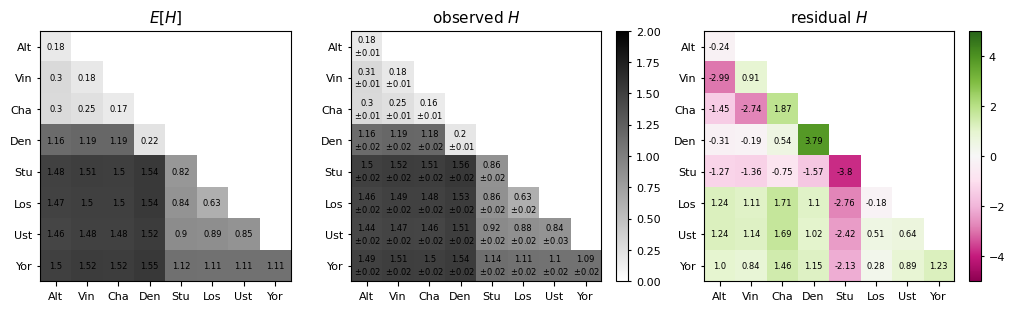

In [235]:
"""
H heatmaps: Zhou data set
"""


zhou_graph = "models/main_models/zhou_full.yaml"
zhou_model = get_model(zhou_graph, zhou_data)
E_H_arr = get_H_arrs(zhou_model)
H_arr, H_stds = get_H_arrs(zhou_data)
pop_ids = bherer_data["pop_ids"]
scale = 1e3
E_H_arr *= scale
H_arr *= scale
H_stds *= scale
residuals = (E_H_arr - H_arr) / H_stds


fig, axs = plt.subplot_mosaic("ABC", figsize=(10, 3), layout="constrained")
cmap = "binary"

im = axs["A"].imshow(E_H_arr, cmap=cmap, vmin=0, vmax=2)
axs["A"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_title("$E[H]$")

im = axs["B"].imshow(H_arr, cmap=cmap, vmin=0, vmax=2)
fig.colorbar(im)
axs["B"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_title("observed $H$")

im = axs["C"].imshow(residuals, cmap="PiYG", vmin=-5, vmax=5)
fig.colorbar(im)
axs["C"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_title("residual $H$")


def annotate(ax, data, stds=None):
    for ii in range(len(pop_ids)):
        for jj in range(ii, len(pop_ids)):
            if stds is None:
                txt = np.round(data[jj, ii], 2)
            else:        
                xx = np.round(data[jj, ii], 2)
                ci = np.round(stds[jj, ii] * 1.96, 2)
                txt = f"{xx}\n $\\pm${ci}"
            ax.text(ii, jj, txt, ha="center", va="center", color="black", size=6)
    return


annotate(axs["A"], E_H_arr)
annotate(axs["B"], H_arr, stds=H_stds)
annotate(axs["C"], residuals)

plt.savefig("figures/zhou_predicted_H.pdf")

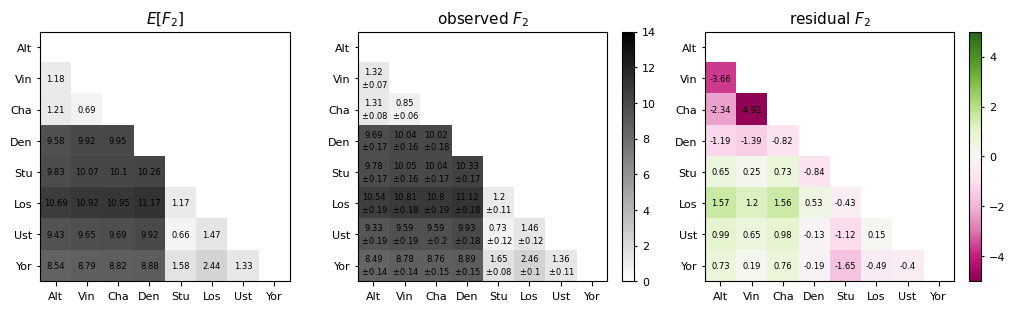

In [234]:
"""
F2 heatmap: Bherer dataset
"""


def compute_F2(Hs):
    stats = dpluspy.datastructures.DPlusStats([Hs], pop_ids=list(range(8)))
    F2 = []
    for ii in range(8):
        for jj in range(ii + 1, 8):
            F2.append(stats.F2(ii, jj))
    return np.array(F2)   


def get_block_F2(input_fname):
    with open(input_fname, "rb") as fin:
        raw_data = pickle.load(fin)
    block_F2s = {}
    for block in raw_data:
        block_L = raw_data[block]["denoms"][-1]
        block_H = raw_data[block]["sums"][-1]
        Hs = block_H / block_L
        Hs = dpluspy.bootstrapping.subset_means(
            [Hs], raw_data[block]["pop_ids"], bherer_data["pop_ids"])[0]
        block_F2 = compute_F2(Hs)
        block_F2s[block] = {"sums": [block_F2 * block_L], "denoms": [block_L]}
    return block_F2s


def get_F2_matrix(data, pop_ids):
    """
    turn a flat array of F2s into a 2dim array.
    """
    n_pops = len(pop_ids)
    matrix = np.full((n_pops, n_pops), np.nan)
    idx = 0
    for ii in range(n_pops):
        for jj in range(ii + 1, n_pops):
            matrix[jj, ii] = data[idx]
            idx += 1
    return matrix


zhou_graph = "models/main_models/zhou_full.yaml"
zhou_model = get_model(zhou_graph, zhou_data)
E_F2 = compute_F2(zhou_model["means"][-1]) 
E_F2_arr = get_F2_matrix(E_F2, zhou_model["pop_ids"])

# mean observed F2
F2 = compute_F2(zhou_data["means"][-1]) 
F2_arr = get_F2_matrix(F2, zhou_data["pop_ids"])

block_F2s = get_block_F2("statistics/main/zhou_weighted_raw_sums.pkl")
samples = dpluspy.bootstrapping.get_bootstrap_reps(block_F2s)
F2_stds = np.std(samples, axis=0)[0]
F2_std_arr = get_F2_matrix(F2_stds, zhou_data["pop_ids"])


scale = 1e4
E_F2_arr *= scale
F2_arr *= scale
F2_std_arr *= scale
residuals = (E_F2_arr - F2_arr) / F2_std_arr

fig, axs = plt.subplot_mosaic("ABC", figsize=(10, 3), layout="constrained")
cmap = "binary"
vmax = 14

im = axs["A"].imshow(E_F2_arr, cmap=cmap, vmin=0, vmax=vmax)
axs["A"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["A"].set_title("$E[F_2]$")

im = axs["B"].imshow(F2_arr, cmap=cmap, vmin=0, vmax=vmax)
fig.colorbar(im)
axs["B"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["B"].set_title("observed $F_2$")

im = axs["C"].imshow(residuals, cmap="PiYG", vmin=-5, vmax=5)
fig.colorbar(im)
axs["C"].set_xticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_yticks(range(len(pop_ids)), [pop_id[:3] for pop_id in pop_ids])
axs["C"].set_title("residual $F_2$")

def annotate(ax, data, stds=None):
    for ii in range(len(pop_ids)):
        for jj in range(ii + 1, len(pop_ids)):
            if stds is None:
                txt = np.round(data[jj, ii], 2)
            else:        
                xx = np.round(data[jj, ii], 2)
                ci = np.round(stds[jj, ii] * 1.96, 2)
                txt = f"{xx}\n $\\pm${ci}"
            ax.text(ii, jj, txt, ha="center", va="center", color="black", size=6)
    return


annotate(axs["A"], E_F2_arr)
annotate(axs["B"], F2_arr, stds=F2_std_arr)
annotate(axs["C"], residuals)

plt.savefig("figures/zhou_predicted_F2.pdf")

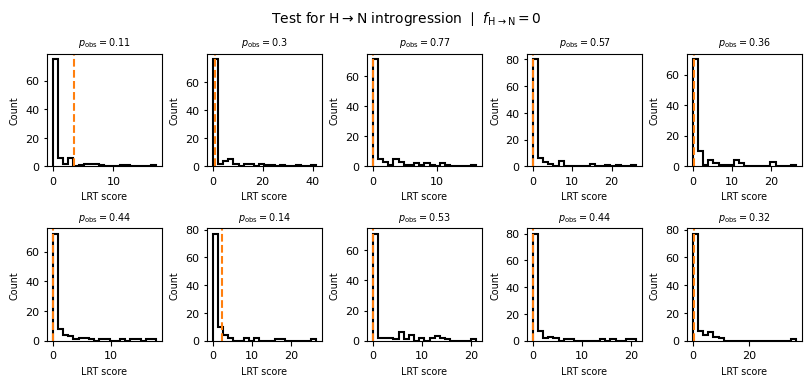

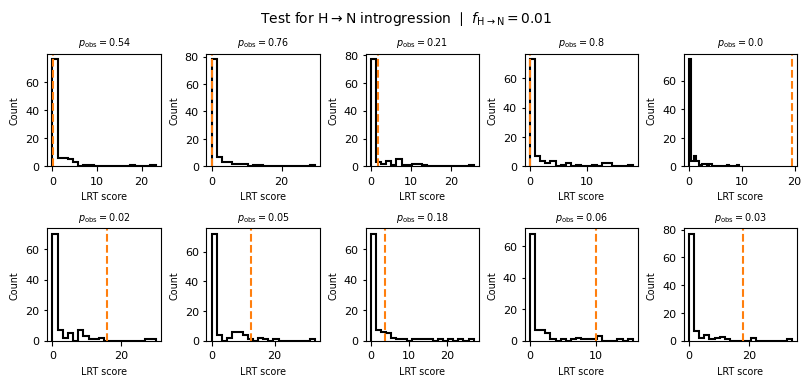

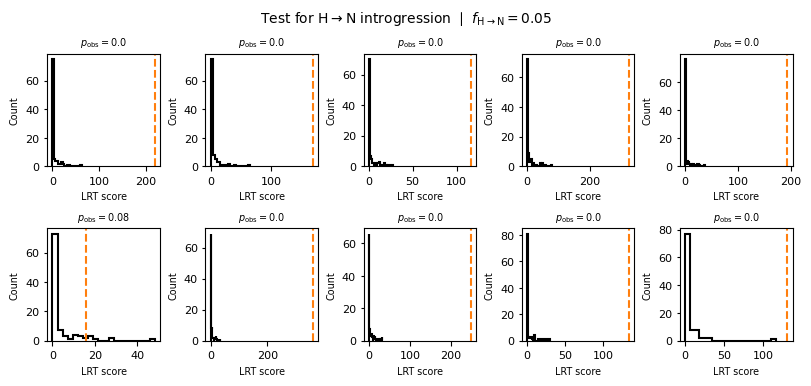

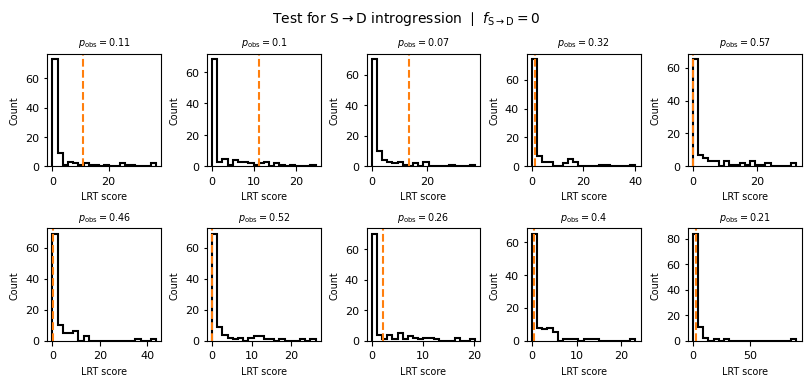

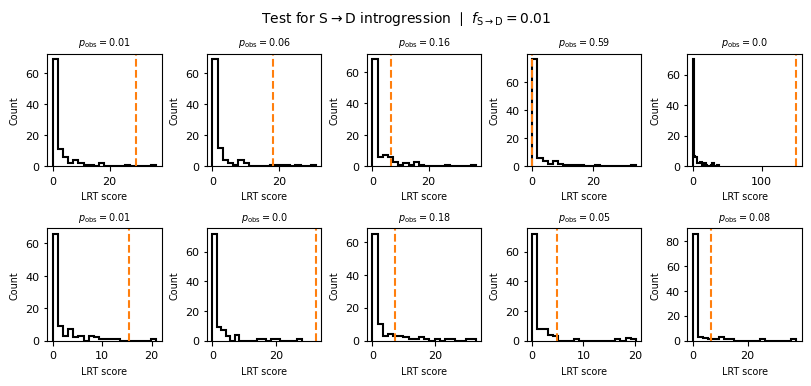

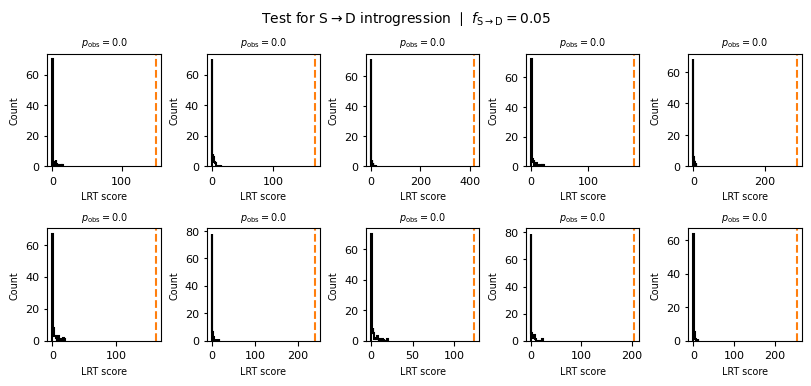

In [140]:
"""
simulated bootstrap LRT results (granular)
"""

def plot_histogram(data, bins, ax, jitter=0, **kwargs):
    histogram = np.histogram(data, bins=bins)[0] / len(data)
    xs = np.concatenate(([1e-10], bins))
    xs += xs * jitter
    ys = np.concatenate(([0], histogram, [0]))
    ax.step(xs, ys, where="post", **kwargs)
    return


whole_results = pandas.read_csv(
    "simulations/bootstrap_lrt_demo/results/data_set_results.csv")

titles = [
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0$",
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0.01$",
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0.05$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0.01$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0.05$",
]

models = [
    "hn_null_model",
    "hn_model_1",
    "hn_model_5",
    "sd_null_model",
    "sd_model_1",
    "sd_model_5"
]


for title, model in zip(titles, models):
    fig, axs = plt.subplots(2, 5, figsize=(8, 3.75), layout="constrained")
    fig.suptitle(title, size="medium")

    for rep, ax in enumerate(axs.flat):
        boot_results = pandas.read_csv(
            f"simulations/bootstrap_lrt_demo/results/{model}_rep_{rep}_samples.csv")
        samples = np.array(boot_results["score"])
        score = list(whole_results[whole_results["trial"] == f"{model}_rep_{rep}"]["score"])[0]
        p_obs = np.count_nonzero(samples > score) / len(samples)
        ax.hist(samples, bins=20, histtype="step", lw=1.5, color="black")
        ax.vlines(score, 0, 1, transform=ax.get_xaxis_transform(), color="tab:orange", linestyle="--")
        ax.set_title(rf"$p_{{\text{{obs}}}}=${np.round(p_obs, 3)}", size="x-small")
        ax.set_ylabel("Count", size="x-small")
        ax.set_xlabel("LRT score", size="x-small")
    plt.savefig(f"figures/sim_blrt_{model}.pdf")

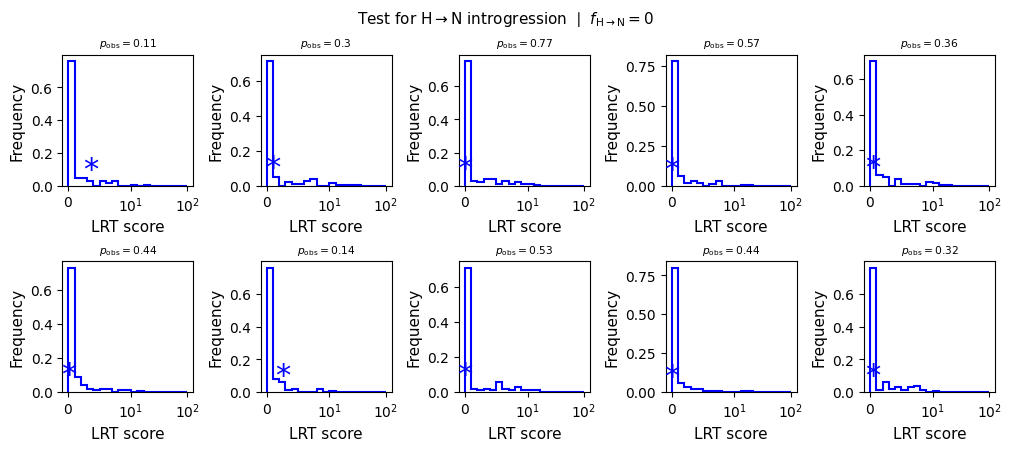

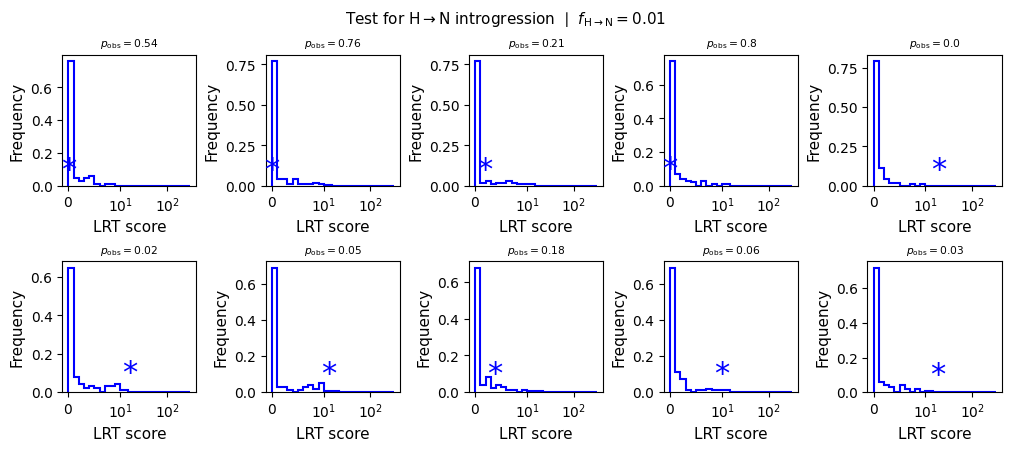

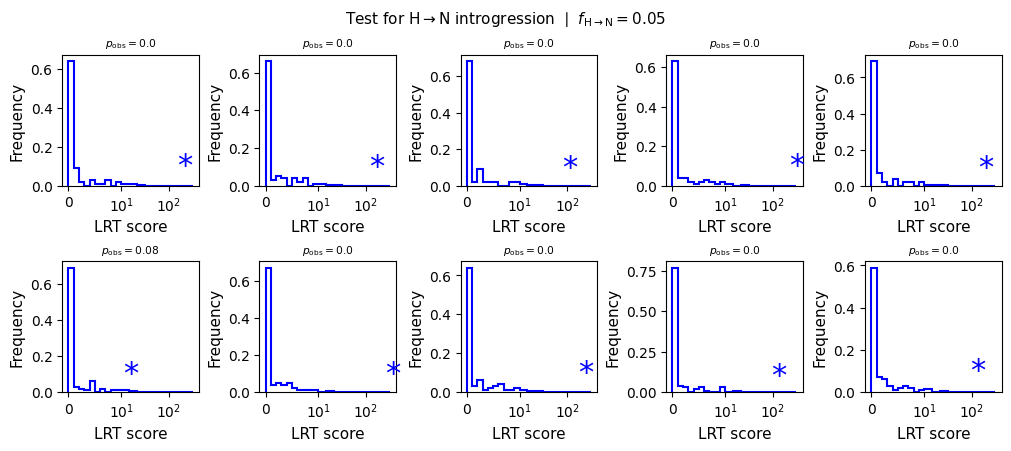

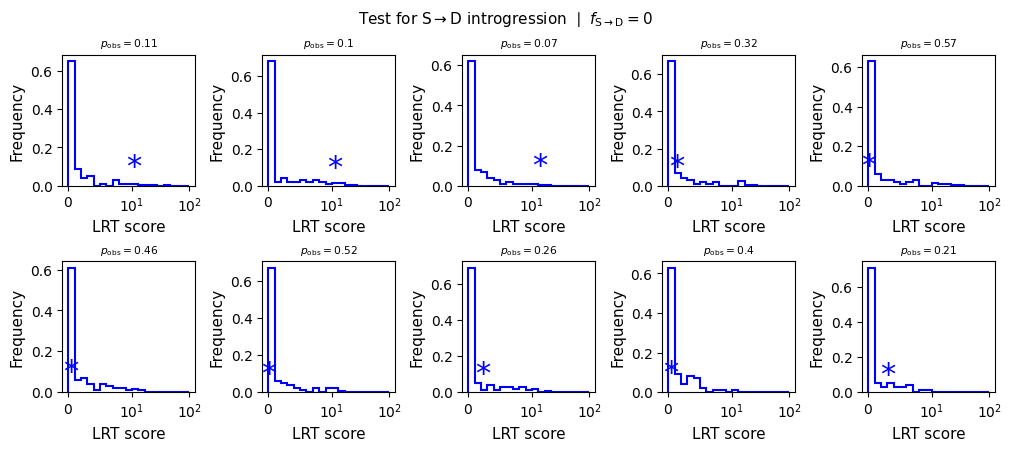

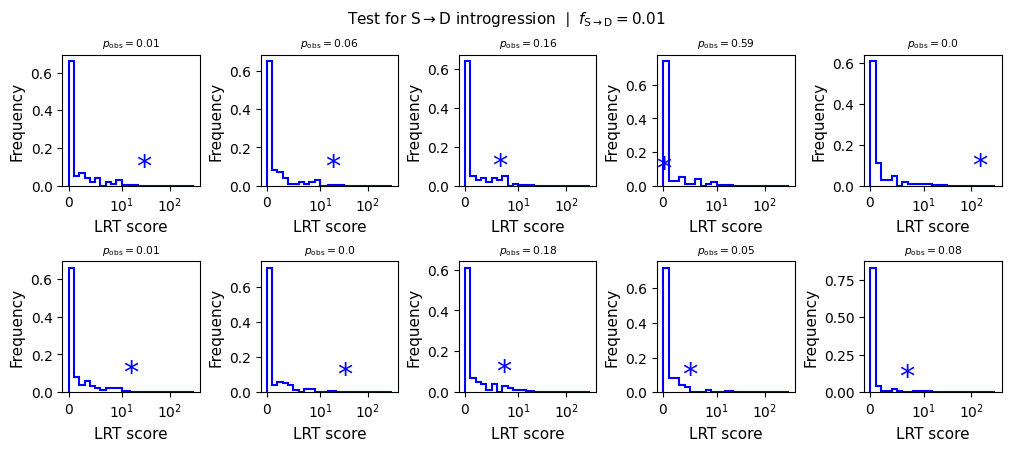

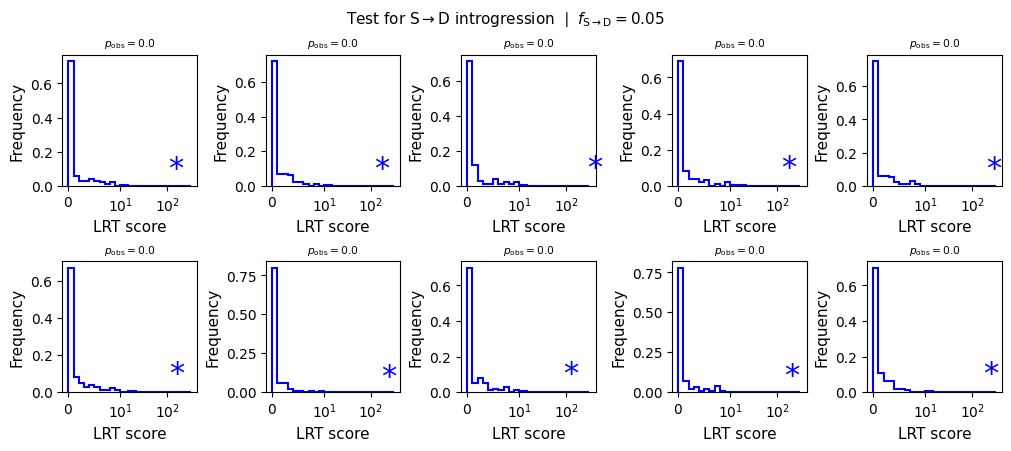

In [24]:
"""
simulated bootstrap LRT results (granular)
"""

def plot_histogram(data, bins, ax, jitter=0, **kwargs):

    return


whole_results = pandas.read_csv(
    "simulations/bootstrap_lrt_demo/results/data_set_results.csv")

titles = [
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0$",
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0.01$",
    r"Test for H$\to$N introgression $\mid$ $f_{\text{H}\to \text{N}} = 0.05$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0.01$",
    r"Test for S$\to$D introgression $\mid$ $f_{\text{S}\to \text{D}} = 0.05$",
]

models = [
    "hn_null_model",
    "hn_model_1",
    "hn_model_5",
    "sd_null_model",
    "sd_model_1",
    "sd_model_5"
]

max_log = {
    "hn_null_model": 2,
    "hn_model_1": 2.5,
    "hn_model_5": 2.5,
    "sd_null_model": 2,
    "sd_model_1": 2.5,
    "sd_model_5": 2.5
}


for title, model in zip(titles, models):
    fig, axs = plt.subplots(2, 5, figsize=(10, 4.4), layout="constrained")
    fig.suptitle(title, size="medium")
    for rep, ax in enumerate(axs.flat):
        boot_results = pandas.read_csv(
            f"simulations/bootstrap_lrt_demo/results/{model}_rep_{rep}_samples.csv")
        samples = np.array(boot_results["score"])
        score = list(whole_results[whole_results["trial"] == f"{model}_rep_{rep}"]["score"])[0]
        p_obs = np.count_nonzero(samples > score) / len(samples)
        bins =  list(np.linspace(0, 9, 10)) + list(np.logspace(1, max_log[model], 10))
        ax.set_xscale("symlog", linthresh=10)
        ax.hist(samples, bins=bins, histtype="step", lw=1.5, density=1, color="blue")
        ax.set_ylabel("Frequency")
        ax.set_xlabel("LRT score")
        ax.text(score, 0.1, "*", horizontalalignment="center", 
            color="blue", fontsize=22, verticalalignment="center")
        
        ax.set_title(rf"$p_{{\text{{obs}}}}=${np.round(p_obs, 3)}", size="x-small")
    plt.savefig(f"figures/sim_blrt_{model}.pdf")

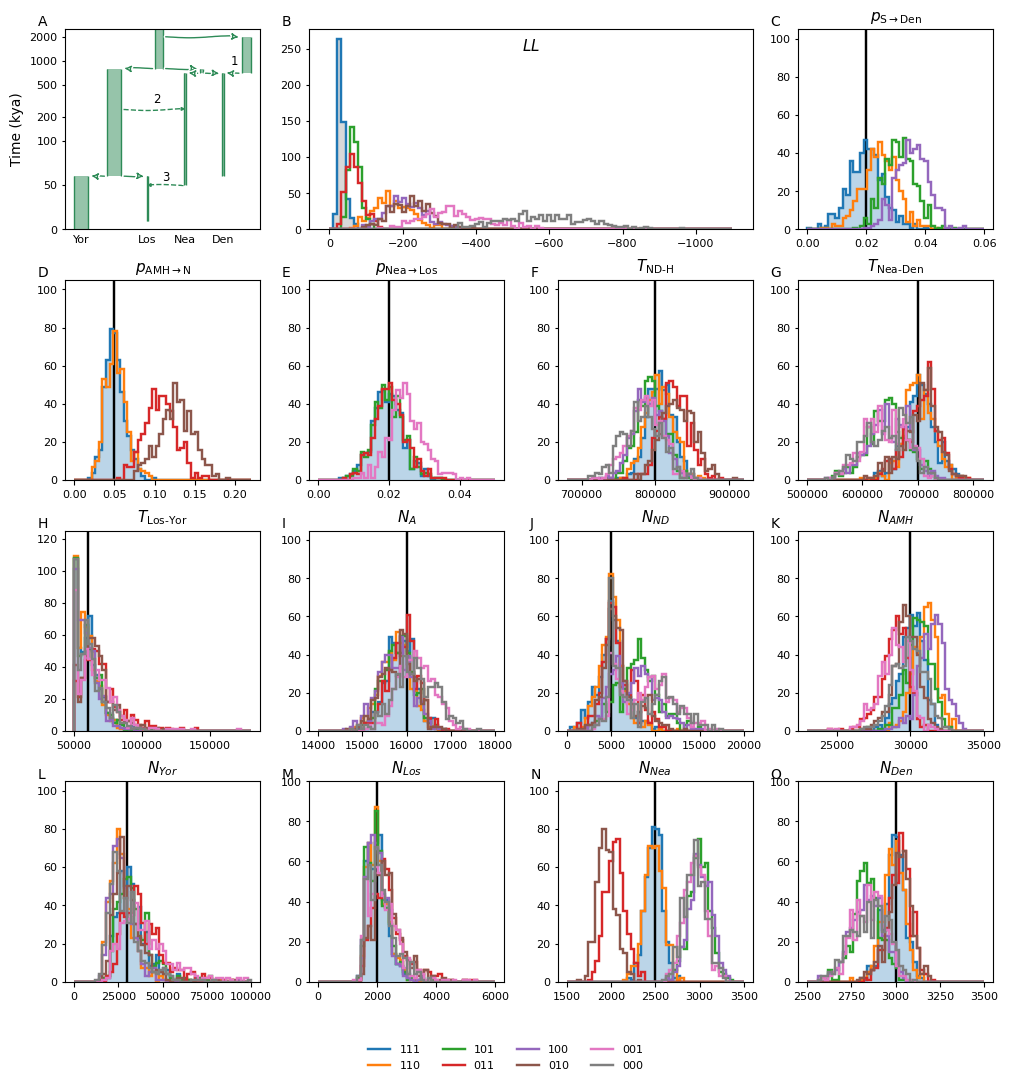

In [103]:
"""
joint inference simulations [plots parameter distributions and LL distributions under true/misspec models]
"""


path = "simulations/joint_inference_demo"
graph_file = f"{path}/models/model_111.yaml"
graph = demes.load(graph_file)
tbls = {
    "111": pandas.read_csv(f"{path}/fits_model_111.csv"),
    "110": pandas.read_csv(f"{path}/fits_model_110.csv"),
    "101": pandas.read_csv(f"{path}/fits_model_101.csv"),
    "011": pandas.read_csv(f"{path}/fits_model_011.csv"),
    "100": pandas.read_csv(f"{path}/fits_model_100.csv"),
    "010": pandas.read_csv(f"{path}/fits_model_010.csv"),
    "001": pandas.read_csv(f"{path}/fits_model_001.csv"),   
    "000": pandas.read_csv(f"{path}/fits_model_000.csv")
}

# figure parameters
colors = bokeh.palettes.Category10_10
_lw = 1.75


mosaic = "ABBC;DEFG;HIJK;LMNO"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(10, 10), layout="constrained")


# plot graph    
positions = {
    "Yor": -4e4,
    "Los": 1e5,
    "Nea": 1.8e5,
    "Den": 2.6e5,
    "Sup": 3.1e5,
    "Afr": 3e4, 
    "ND": 2.15e5,
    "Anc": 1.25e5,
}
demesdraw.tubes(graph, ax=axs["A"], colours="seagreen", labels=None, positions=positions)    
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)    
axs["A"].set_yscale("symlog", linthresh=1e5)
axs["A"].set_ylabel("Time (kya)")
yticks = [0, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6]
axs["A"].set_yticks(yticks, np.array(yticks).astype(np.int64) // 1000)
label_me = ["Yor", "Los", "Nea", "Den"]
axs["A"].set_xticks([positions[label] for label in label_me], label_me)
axs["A"].text(2.85e5, 9e5, "1", horizontalalignment="center", fontsize="small")
axs["A"].text(1.2e5, 3e5, "2", horizontalalignment="center", fontsize="small")
axs["A"].text(1.4e5, 5.5e4, "3", horizontalalignment="center", fontsize="small")


# plot likelihoods
ll_bins = np.linspace(-1100, 0, 101)
for ii, model in enumerate(tbls):
    tbl = tbls[model]
    if model == "111":
        axs["B"].hist(tbl["ll"], bins=ll_bins, color=colors[jj], alpha=0.3)
    axs["B"].hist(tbl["ll"], bins=ll_bins, color=colors[ii], histtype="step", lw=_lw)
axs["B"].invert_xaxis()
axs["B"].set_ylim(0, )
axs["B"].set_title("$LL$", y=0.85)


# plot parameters
options_file = f"{path}/models/model_111_params.yaml"
param_names, true_vals = dpluspy.inference._load_params(graph_file, options_file)
params_labels = {
    "p_S_D": (r"$p_{\text{S}\to\text{Den}}$", (0, 0.06, 105)),
    "p_H_N": (r"$p_{\text{AMH}\to\text{N}}$", (0, 0.22, 105)),
    "p_N_Los": (r"$p_{\text{Nea}\to\text{Los}}$", (0, 0.05, 105)),
    "T_NDH": (r"$T_{\text{ND-H}}$", (6.8e5, 9.2e5, 105)),
    "T_ND": (r"$T_{\text{Nea-Den}}$", (5e5, 8.2e5, 105)),
    "T_LY": (r"$T_{\text{Los-Yor}}$", (5e4, 1.8e5, 125)),
    "N_A": (r"$N_{A}$", (1.4e4, 1.8e4, 105)),
    "N_ND": (r"$N_{ND}$", (0, 2e4, 105)),
    "N_Afr": (r"$N_{AMH}$", (2.3e4, 3.5e4, 105)),
    "N_Yor": (r"$N_{Yor}$", (0, 1e5, 105)),
    "N_Los": (r"$N_{Los}$", (0, 6e3, 100)),
    "N_Nea": (r"$N_{Nea}$", (1.5e3, 3.5e3, 105)),
    "N_Den": (r"$N_{Den}$", (2.5e3, 3.5e3, 100)),
}

fig_keys = mosaic.replace(";", "")
for ii, (param, specs) in enumerate(params_labels.items()):
    label, (xmin, xmax, ymax) = specs
    ax = axs[fig_keys[ii + 3]]
    ax.set_title(label)
    ax.vlines([true_vals[param_names.index(param)]], [0], [ymax], colors=["black"], lw=_lw)
    
    # determine min/max values
    #min_val = np.inf
    #max_val = 0
    #for jj, model in enumerate(tbls):
    #    tbl = tbls[model]
    #    if param in tbl.columns:
    #        min_val = np.min([min_val, np.min(tbl[param])])
    #        max_val = np.max([max_val, np.max(tbl[param])])
    # bins = np.linspace(min_val * 0.95, max_val * 1.05, 31)
    bins = np.linspace(xmin, xmax, 51)
    
    for jj, model in enumerate(tbls):
        tbl = tbls[model]
        if param in tbl.columns:
            if model == "111":
                ax.hist(tbl[param], bins=bins, color=colors[jj], alpha=0.3)
            ax.hist(tbl[param], bins=bins, color=colors[jj], histtype="step", lw=_lw)
    ax.set_ylim(0, ymax)


labels = [matplotlib.lines.Line2D([], [], lw=_lw, color=color, label=model) for color, model in zip(colors, tbls.keys())]
fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.075))
label_axs(fig, axs)
plt.savefig("figures/joint_inference.pdf")

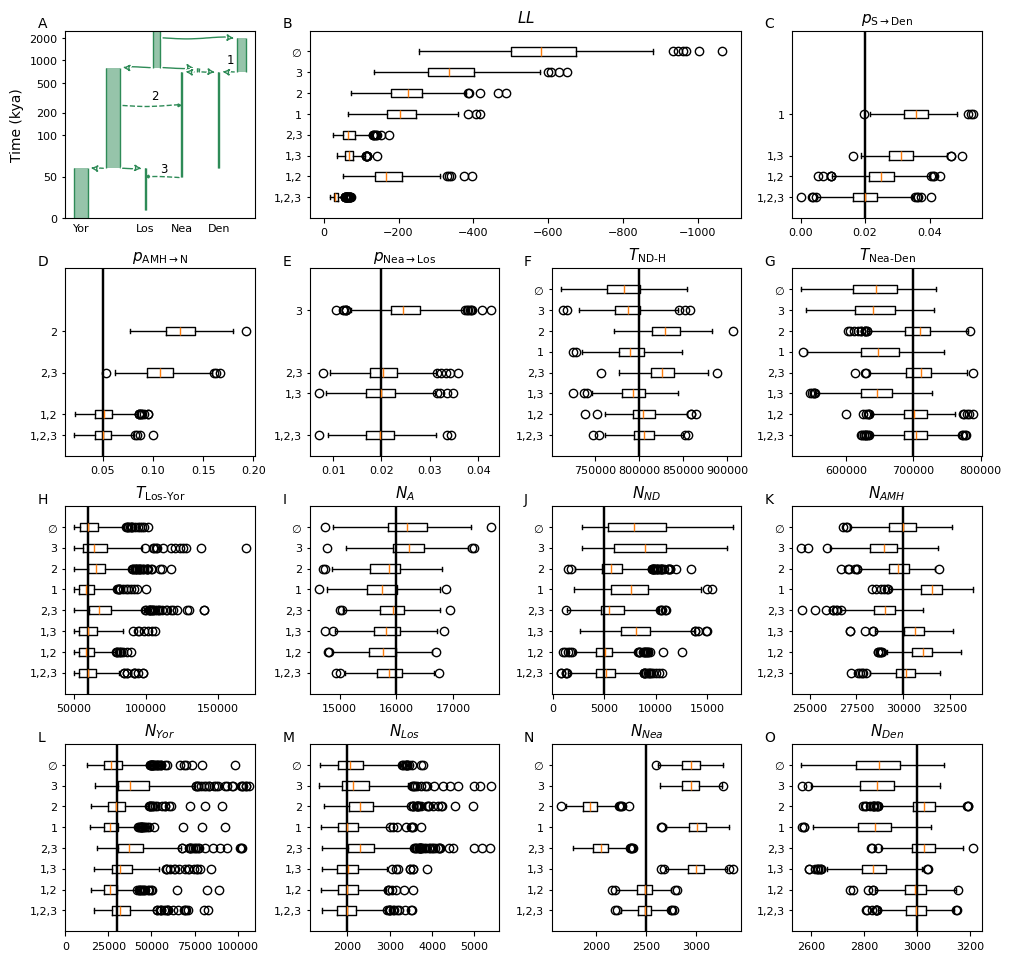

In [246]:
"""
Box plot version of the above
"""


path = "simulations/joint_inference_demo"
graph_file = f"{path}/models/model_111.yaml"
graph = demes.load(graph_file)
tbls = {
    "111": pandas.read_csv(f"{path}/fits_model_111.csv"),
    "110": pandas.read_csv(f"{path}/fits_model_110.csv"),
    "101": pandas.read_csv(f"{path}/fits_model_101.csv"),
    "011": pandas.read_csv(f"{path}/fits_model_011.csv"),
    "100": pandas.read_csv(f"{path}/fits_model_100.csv"),
    "010": pandas.read_csv(f"{path}/fits_model_010.csv"),
    "001": pandas.read_csv(f"{path}/fits_model_001.csv"),   
    "000": pandas.read_csv(f"{path}/fits_model_000.csv")
}

model_labels = {
    "111": "1,2,3",
    "110": "1,2",
    "101": "1,3",
    "011": "2,3",
    "100": "1",
    "010": "2",
    "001": "3",
    "000": r"$\varnothing$",
}

# figure parameters
colors = bokeh.palettes.Category10_10
_lw = 1.75


mosaic = "ABBC;DEFG;HIJK;LMNO"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(10, 9.5), layout="constrained")


# plot graph    
positions = {
    "Yor": -4e4,
    "Los": 1e5,
    "Nea": 1.8e5,
    "Den": 2.6e5,
    "Sup": 3.1e5,
    "Afr": 3e4, 
    "ND": 2.15e5,
    "Anc": 1.25e5,
}
demesdraw.tubes(graph, ax=axs["A"], colours="seagreen", labels=None, positions=positions)    
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)    
axs["A"].set_yscale("symlog", linthresh=1e5)
axs["A"].set_ylabel("Time (kya)")
yticks = [0, 5e4, 1e5, 2e5, 5e5, 1e6, 2e6]
axs["A"].set_yticks(yticks, np.array(yticks).astype(np.int64) // 1000)
label_me = ["Yor", "Los", "Nea", "Den"]
axs["A"].set_xticks([positions[label] for label in label_me], label_me)
axs["A"].text(2.85e5, 9e5, "1", horizontalalignment="center", fontsize="small")
axs["A"].text(1.2e5, 3e5, "2", horizontalalignment="center", fontsize="small")
axs["A"].text(1.4e5, 5.5e4, "3", horizontalalignment="center", fontsize="small")


# plot likelihoods
ll_bins = np.linspace(-1100, 0, 101)
for ii, model in enumerate(tbls):
    tbl = tbls[model]
    axs["B"].boxplot([tbl["ll"]], positions=[ii], tick_labels=[model_labels[model]], orientation="horizontal", widths=[0.4])
axs["B"].invert_xaxis()
axs["B"].set_ylim(0, )
axs["B"].set_title("$LL$")
axs["B"].set_ylim(-1, 8)


# plot parameters
options_file = f"{path}/models/model_111_params.yaml"
param_names, true_vals = dpluspy.inference._load_params(graph_file, options_file)
params_labels = {
    "p_S_D": (r"$p_{\text{S}\to\text{Den}}$", (0, 0.06, 105)),
    "p_H_N": (r"$p_{\text{AMH}\to\text{N}}$", (0, 0.22, 105)),
    "p_N_Los": (r"$p_{\text{Nea}\to\text{Los}}$", (0, 0.05, 105)),
    "T_NDH": (r"$T_{\text{ND-H}}$", (6.8e5, 9.2e5, 105)),
    "T_ND": (r"$T_{\text{Nea-Den}}$", (5e5, 8.2e5, 105)),
    "T_LY": (r"$T_{\text{Los-Yor}}$", (5e4, 1.8e5, 125)),
    "N_A": (r"$N_{A}$", (1.4e4, 1.8e4, 105)),
    "N_ND": (r"$N_{ND}$", (0, 2e4, 105)),
    "N_Afr": (r"$N_{AMH}$", (2.3e4, 3.5e4, 105)),
    "N_Yor": (r"$N_{Yor}$", (0, 1e5, 105)),
    "N_Los": (r"$N_{Los}$", (0, 6e3, 100)),
    "N_Nea": (r"$N_{Nea}$", (1.5e3, 3.5e3, 105)),
    "N_Den": (r"$N_{Den}$", (2.5e3, 3.5e3, 100)),
}

fig_keys = mosaic.replace(";", "")
for ii, (param, specs) in enumerate(params_labels.items()):
    label, (xmin, xmax, ymax) = specs
    ax = axs[fig_keys[ii + 3]]
    ax.set_title(label)
    ax.vlines([true_vals[param_names.index(param)]], [-1], [8], colors=["black"], lw=_lw)
    
    for jj, model in enumerate(tbls):
        tbl = tbls[model]
        if param in tbl.columns:
            ax.boxplot([tbl[param]], positions=[jj], tick_labels=[model_labels[model]], orientation="horizontal", widths=[0.4])
    ax.set_ylim(-1, 8)

axs["L"].set_xlim(0, 1.1e5)

# labels = [matplotlib.lines.Line2D([], [], lw=_lw, color=color, label=model) for color, model in zip(colors, tbls.keys())]
# fig.legend(handles=labels, framealpha=0, loc="lower center", ncols=4, bbox_to_anchor=(0.5, -0.075))
label_axs(fig, axs)
plt.savefig("figures/joint_inference_boxplots.pdf")